In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from glob import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.cluster as sk
import plotly.graph_objects as go
from scipy.cluster.hierarchy import dendrogram
from scipy import stats

import thicket as tt

In [2]:
gpu_kernels = {
    "block_256": [
        "Algorithm_ATOMIC",
        "Algorithm_MEMCPY",
        "Algorithm_MEMSET",
        "Apps_DEL_DOT_VEC_2D",
        "Apps_EDGE3D",
        "Apps_ENERGY",
        "Apps_FIR",
        "Apps_LTIMES",
        "Apps_LTIMES_NOVIEW",
        "Apps_MATVEC_3D_STENCIL",
        "Apps_NODAL_ACCUMULATION_3D",
        "Apps_PRESSURE",
        "Apps_VOL3D",
        "Apps_ZONAL_ACCUMULATION_3D",
        "Basic_ARRAY_OF_PTRS",
        "Basic_COPY8",
        "Basic_DAXPY",
        "Basic_DAXPY_ATOMIC",
        "Basic_IF_QUAD",
        "Basic_INDEXLIST",
        "Basic_INDEXLIST_3LOOP",
        "Basic_INIT3",
        "Basic_INIT_VIEW1D",
        "Basic_INIT_VIEW1D_OFFSET",
        "Basic_MAT_MAT_SHARED",
        "Basic_MULADDSUB",
        "Basic_NESTED_INIT",
        "Basic_PI_ATOMIC",
        "Comm_HALO_EXCHANGE",
        "Comm_HALO_PACKING",
        "Comm_HALO_SENDRECV",
        "Lcals_DIFF_PREDICT",
        "Lcals_EOS",
        "Lcals_FIRST_DIFF",
        "Lcals_FIRST_SUM",
        "Lcals_GEN_LIN_RECUR",
        "Lcals_HYDRO_1D",
        "Lcals_HYDRO_2D",
        "Lcals_INT_PREDICT",
        "Lcals_PLANCKIAN",
        "Lcals_TRIDIAG_ELIM",
        "Polybench_2MM",
        "Polybench_3MM",
        "Polybench_ADI",
        "Polybench_ATAX",
        "Polybench_FDTD_2D",
        "Polybench_FLOYD_WARSHALL",
        "Polybench_GEMM",
        "Polybench_GEMVER",
        "Polybench_GESUMMV",
        "Polybench_HEAT_3D",
        "Polybench_JACOBI_1D",
        "Polybench_JACOBI_2D",
        "Polybench_MVT",
        "Stream_ADD",
        "Stream_COPY",
        "Stream_MUL",
        "Stream_TRIAD",
    ], # For block_256
    # "default": [
    #     "Algorithm_SORT",
    #     "Algorithm_SORTPAIRS",
    # ], # For default
#     "blkatm_occgs_256": [
#         "Algorithm_REDUCE_SUM",
#         "Basic_PI_REDUCE",
#         "Basic_REDUCE3_INT",
#         "Basic_REDUCE_STRUCT",
#         "Basic_TRAP_INT",
# #    ], "blkatm_direct_256": [
#         "Stream_DOT",
#     ], # For blkatm_occgs_256
    "block_64": [
        "Apps_CONVECTION3DPA",
        "Apps_DIFFUSION3DPA",
        "Apps_MASS3DEA",
    ], # For block_64
    "block_25": [
        "Apps_MASS3DPA",
    ], # For block_25
    # "funcptr_256": [
    #     "Comm_HALO_EXCHANGE_FUSED",
    #     "Comm_HALO_PACKING_FUSED",
    # ], # For funcptr_256
    # "rocprim": [
    #     "Algorithm_SCAN",
    # ], # For rocprim
#     "atomic_occgs_256": [
#         "Algorithm_HISTOGRAM",
# #    ], "atomic_direct_256": [
#         "Basic_MULTI_REDUCE",
#     ], # For atomic_occgs_256
    # "blkdev_occgs_256": [
    #     "Lcals_FIRST_MIN",
    # ], # For blkdev_occgs_256
    # "cub": [
    #     "Algorithm_SCAN",
    # ], # For cub
}

spr_kernels = {
    "default": [
        "Algorithm_ATOMIC",
        "Algorithm_HISTOGRAM",
        "Algorithm_MEMCPY",
        "Algorithm_MEMSET",
        "Algorithm_SCAN",
        "Algorithm_SORT",
        "Algorithm_SORTPAIRS",
        "Algorithm_REDUCE_SUM",
        "Apps_CONVECTION3DPA",
        "Apps_DEL_DOT_VEC_2D",
        "Apps_DIFFUSION3DPA",
        "Apps_EDGE3D",
        "Apps_ENERGY",
        "Apps_FIR",
        "Apps_LTIMES",
        "Apps_LTIMES_NOVIEW",
        "Apps_MASS3DEA",
        "Apps_MASS3DPA",
        "Apps_MATVEC_3D_STENCIL",
        "Apps_NODAL_ACCUMULATION_3D",
        "Apps_PRESSURE",
        "Apps_VOL3D",
        "Apps_ZONAL_ACCUMULATION_3D",
        "Basic_ARRAY_OF_PTRS",
        "Basic_COPY8",
        "Basic_DAXPY",
        "Basic_DAXPY_ATOMIC",
        "Basic_IF_QUAD",
        "Basic_INDEXLIST",
        "Basic_INDEXLIST_3LOOP",
        "Basic_INIT3",
        "Basic_INIT_VIEW1D",
        "Basic_INIT_VIEW1D_OFFSET",
        "Basic_MAT_MAT_SHARED",
        "Basic_MULADDSUB",
        "Basic_MULTI_REDUCE",
        "Basic_NESTED_INIT",
        "Basic_PI_ATOMIC",
        "Basic_PI_REDUCE",
        "Basic_REDUCE_STRUCT",
        "Basic_REDUCE3_INT",
        "Basic_TRAP_INT",
        "Comm_HALO_EXCHANGE",
        "Comm_HALO_PACKING",
        "Comm_HALO_SENDRECV",
        "Lcals_DIFF_PREDICT",
        "Lcals_EOS",
        "Lcals_FIRST_DIFF",
        "Lcals_FIRST_MIN",
        "Lcals_FIRST_SUM",
        "Lcals_GEN_LIN_RECUR",
        "Lcals_HYDRO_1D",
        "Lcals_HYDRO_2D",
        "Lcals_INT_PREDICT",
        "Lcals_PLANCKIAN",
        "Lcals_TRIDIAG_ELIM",
        "Polybench_2MM",
        "Polybench_3MM",
        "Polybench_ADI",
        "Polybench_ATAX",
        "Polybench_FDTD_2D",
        "Polybench_FLOYD_WARSHALL",
        "Polybench_GEMM",
        "Polybench_GEMVER",
        "Polybench_GESUMMV",
        "Polybench_HEAT_3D",
        "Polybench_JACOBI_1D",
        "Polybench_JACOBI_2D",
        "Polybench_MVT",
        "Stream_ADD",
        "Stream_COPY",
        "Stream_DOT",
        "Stream_MUL",
        "Stream_TRIAD",
    ], # default
    # "funcptr": [
    #     "Comm_HALO_EXCHANGE_FUSED",
    #     "Comm_HALO_PACKING_FUSED",
    # ], # For funcptr
}

# List of kernels to exclude from the data, agnostic of parameters
exclude_kernels = [
    "Algorithm_ATOMIC",
    "Algorithm_HISTOGRAM",
    "Algorithm_REDUCE_SUM",
    "Algorithm_SCAN",
    "Algorithm_SORT",
    "Algorithm_SORTPAIRS",

    "Apps_NODAL_ACCUMULATION_3D",

    "Basic_INDEXLIST",
    "Basic_INDEXLIST_3LOOP", 
    "Basic_MULTI_REDUCE",
    "Basic_PI_ATOMIC",
    "Basic_PI_REDUCE",
    "Basic_REDUCE_STRUCT",
    "Basic_REDUCE3_INT",
    "Basic_TRAP_INT",
    
    "Lcals_FIRST_MIN",

    "Comm_HALO_EXCHANGE",
    "Comm_HALO_EXCHANGE_FUSED",
    "Comm_HALO_SENDRECV",
    "Comm_HALO_EXCHANGE_FUSED",
    "Comm_HALO_PACKING_FUSED",

    "Polybench_GEMM",
    "Polybench_GEMVER",
    "Polybench_GESUMMV",

    "Stream_DOT",
]

In [3]:
def kernel_query(kernel_list):
    return tt.query.Query().match(
        ".",
        lambda row: row["name"].apply(
            lambda n: n in kernel_list
        ).all()
    ).rel("*")

def not_kernel_query(kernel_list):
    return tt.query.Query().match(
        ".",
        lambda row: row["name"].apply(
            lambda n: n not in kernel_list
        ).all()
    ).rel("*")

In [4]:
#maindir = "/usr/workspace/thicket/"
maindir = "/Users/michaelmckinsey/Documents/data/"

In [5]:
data = maindir+"RAJAPerf-version-2024.07.0/grace-cascadelake-a100/notools_1GPU_results_GCC-11.3.0-CUDA-12.2.2/RAJA_CUDA/block_256/"

In [6]:
tk = tt.Thicket.from_caliperreader(glob(data+"**/*.cali", recursive=True), fill_perfdata=False)

(2/2) Creating Thicket: 100%|██████████| 139/139 [00:02<00:00, 56.89it/s]


In [7]:
tk = tk.query(kernel_query(gpu_kernels["block_256"]), multi_index_mode="all").query(not_kernel_query(exclude_kernels), multi_index_mode="all")

In [8]:
tk2 = tk.deepcopy()

In [9]:
tk = tk.groupby("ProblemSizeRunParam").agg(np.mean)

In [10]:
tk.dataframe

nid_mean  \
node                                             ProblemSizeRunParam             
{'name': 'Algorithm_MEMCPY', 'type': 'function'} 8192                     60.0   
                                                 16384                    60.0   
                                                 32768                    60.0   
                                                 65536                    60.0   
                                                 131072                   60.0   
...                                                                        ...   
{'name': 'Stream_TRIAD', 'type': 'function'}     4194304                  45.0   
                                                 8388608                  45.0   
                                                 16777216                 45.0   
                                                 33554432                 45.0   
                                                 67108864                 45.0   

                                                                      Min time/rank_mean  \
node                                             ProblemSizeRunParam                       
{'name': 'Algorithm_MEMCPY', 'type': 'function'} 8192                           0.001802   
                                                 16384                          0.001832   
                                                 32768                          0.001896   
                                                 65536                          0.001928   
                                                 131072                         0.002086   
...                                                                                  ...   
{'name': 'Stream_TRIAD', 'type': 'function'}     4194304                        0.387889   
                                                 8388608                        0.754220   
                                                 16777216                       1.494191   
                                                 33554432                       2.966140   
                                                 67108864                       5.926815   

                                                                      Max time/rank_mean  \
node                                             ProblemSizeRunParam                       
{'name': 'Algorithm_MEMCPY', 'type': 'function'} 8192                           0.001802   
                                                 16384                          0.001832   
                                                 32768                          0.001896   
                                                 65536                          0.001928   
                                                 131072                         0.002086   
...                                                                                  ...   
{'name': 'Stream_TRIAD', 'type': 'function'}     4194304                        0.387889   
                                                 8388608                        0.754220   
                                                 16777216                       1.494191   
                                                 33554432                       2.966140   
                                                 67108864                       5.926815   

                                                                      Avg time/rank_mean  \
node                                             ProblemSizeRunParam                       
{'name': 'Algorithm_MEMCPY', 'type': 'function'} 8192                           0.001802   
                                                 16384                          0.001832   
                                                 32768                          0.001896   
                                                 65536                          0.001928   
                                                 131072  

In [11]:
#192KB/SM = 192,000 B ? * 108SM?
# 40,960 KB = 40,960,000 B

In [12]:
timestep_mapping = {
    "Polybench_ADI": 4,
    "Polybench_FDTD_2D": 40,
    "Polybench_JACOBI_1D": 16,
    "Polybench_HEAT_3D": 20,
    "Polybench_JACOBI_2D": 40,
}

tk.dataframe["tsteps"] = tk.dataframe["name"].apply(lambda kernel_name: timestep_mapping[kernel_name] if kernel_name in timestep_mapping else 1)

In [13]:
# tkmap[a100_bytes_read_per_rep_scaled[0]].dataframe[a100_bytes_read_per_rep_scaled[1]] = tkmap[a100_bytes_read_per_rep[0]].dataframe[a100_bytes_read_per_rep[1]] / tkmap[a100_tsteps[0]].dataframe[a100_tsteps[1]] / tkmap[a100_problem_size[0]].dataframe[a100_problem_size[1]]
# tkmap[a100_bytes_write_per_rep_scaled[0]].dataframe[a100_bytes_write_per_rep_scaled[1]] = tkmap[a100_bytes_write_per_rep[0]].dataframe[a100_bytes_write_per_rep[1]] / tkmap[a100_tsteps[0]].dataframe[a100_tsteps[1]] / tkmap[a100_problem_size[0]].dataframe[a100_problem_size[1]]

# tkmap[a100_bytes_per_rep_scaled[0]].dataframe[a100_bytes_per_rep_scaled[1]] = tkmap[a100_bytes_read_per_rep_scaled[0]].dataframe[a100_bytes_read_per_rep_scaled[1]] + tkmap[a100_bytes_write_per_rep_scaled[0]].dataframe[a100_bytes_write_per_rep_scaled[1]]

In [14]:
tk.dataframe["BytesRead/Rep_mean"] = tk.dataframe["BytesRead/Rep_mean"] / tk.dataframe["tsteps"]
tk.dataframe["BytesWritten/Rep_mean"] = tk.dataframe["BytesWritten/Rep_mean"] / tk.dataframe["tsteps"]

In [15]:
# MEM BW
tk.dataframe["Memory Bandwidth (GB/s)"] = (tk.dataframe["BytesRead/Rep_mean"] + tk.dataframe["BytesWritten/Rep_mean"]) * tk.dataframe["Reps_mean"] / tk.dataframe["Avg time/rank_mean"] / (10**9)

In [16]:
tk.dataframe["Bytes"] = (tk.dataframe["BytesRead/Rep_mean"] + tk.dataframe["BytesWritten/Rep_mean"]) * tk.dataframe["Reps_mean"]

In [17]:
tk.dataframe["Bytes/Rep/Problem Size"] = tk.dataframe["Bytes/Rep_mean"] / tk.dataframe["ProblemSize_mean"]

In [18]:
tk.dataframe["Avg time/rank/Kernel"] = tk.dataframe["Avg time/rank_mean"] / tk.dataframe["Reps_mean"] / tk.dataframe["Kernels/Rep_mean"]

In [19]:
pd.set_option('display.max_columns', 500)

In [20]:
tk.dataframe

nid_mean  \
node                                             ProblemSizeRunParam             
{'name': 'Algorithm_MEMCPY', 'type': 'function'} 8192                     60.0   
                                                 16384                    60.0   
                                                 32768                    60.0   
                                                 65536                    60.0   
                                                 131072                   60.0   
...                                                                        ...   
{'name': 'Stream_TRIAD', 'type': 'function'}     4194304                  45.0   
                                                 8388608                  45.0   
                                                 16777216                 45.0   
                                                 33554432                 45.0   
                                                 67108864                 45.0   

                                                                      Min time/rank_mean  \
node                                             ProblemSizeRunParam                       
{'name': 'Algorithm_MEMCPY', 'type': 'function'} 8192                           0.001802   
                                                 16384                          0.001832   
                                                 32768                          0.001896   
                                                 65536                          0.001928   
                                                 131072                         0.002086   
...                                                                                  ...   
{'name': 'Stream_TRIAD', 'type': 'function'}     4194304                        0.387889   
                                                 8388608                        0.754220   
                                                 16777216                       1.494191   
                                                 33554432                       2.966140   
                                                 67108864                       5.926815   

                                                                      Max time/rank_mean  \
node                                             ProblemSizeRunParam                       
{'name': 'Algorithm_MEMCPY', 'type': 'function'} 8192                           0.001802   
                                                 16384                          0.001832   
                                                 32768                          0.001896   
                                                 65536                          0.001928   
                                                 131072                         0.002086   
...                                                                                  ...   
{'name': 'Stream_TRIAD', 'type': 'function'}     4194304                        0.387889   
                                                 8388608                        0.754220   
                                                 16777216                       1.494191   
                                                 33554432                       2.966140   
                                                 67108864                       5.926815   

                                                                      Avg time/rank_mean  \
node                                             ProblemSizeRunParam                       
{'name': 'Algorithm_MEMCPY', 'type': 'function'} 8192                           0.001802   
                                                 16384                          0.001832   
                                                 32768                          0.001896   
                                                 65536                          0.001928   
                                                 131072  

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                               36.378513              0.000004
16384                              71.558820              0.000004
32768                             138.289538              0.000004
65536                             271.988205              0.000004
131072                            502.777170              0.000004
262144                            906.640439              0.000005
524288                           1473.460635              0.000006
1048576                          2191.403676              0.000008
2097152                          1252.001821              0.000027
4194304                          1255.382377              0.000053
8388608                          1323.008924              0.000101
16777216                         1330.172533              0.000202
33554432                         1357.157338              0.00

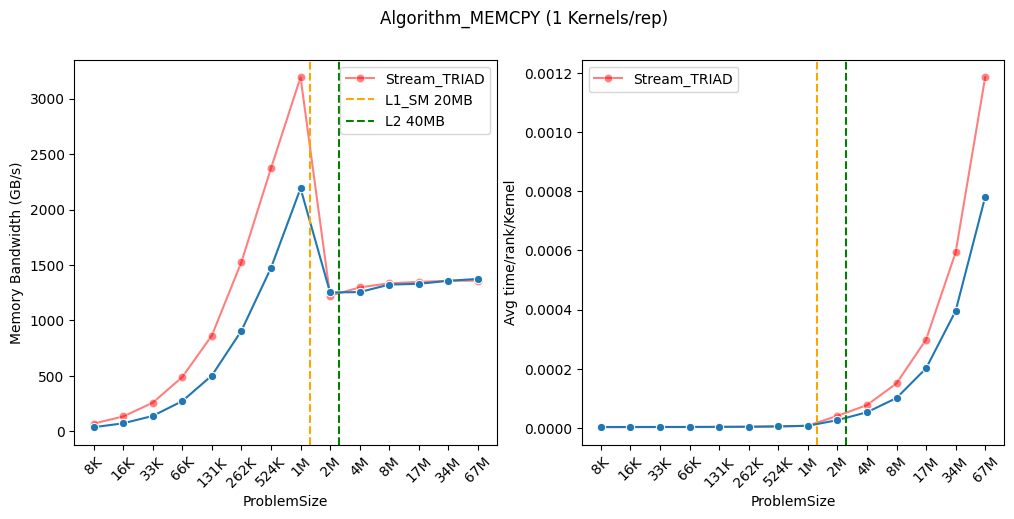

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                               19.291533              0.000003
16384                              37.193591              0.000004
32768                              73.341313              0.000004
65536                             144.274010              0.000004
131072                            275.567913              0.000004
262144                            504.716609              0.000004
524288                            820.097802              0.000005
1048576                          1238.852907              0.000007
2097152                          1693.230670              0.000010
4194304                          1322.755828              0.000025
8388608                          1428.487196              0.000047
16777216                         1488.712481              0.000090
33554432                         1386.124002              0.00

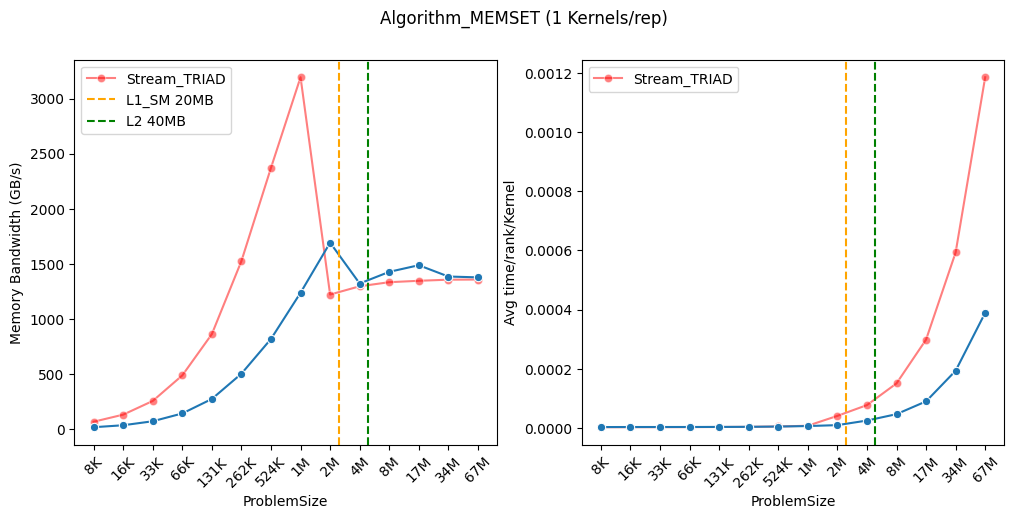

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                               77.642424              0.000005
16384                             153.131026              0.000005
32768                             269.164360              0.000006
65536                             475.484093              0.000007
131072                            817.314725              0.000008
262144                           1305.754147              0.000010
524288                           1566.289653              0.000016
1048576                          1133.944482              0.000044
2097152                          1222.904105              0.000082
4194304                          1280.557284              0.000157
8388608                          1302.878251              0.000309
16777216                         1306.749517              0.000616
33554432                         1288.694649              0.00

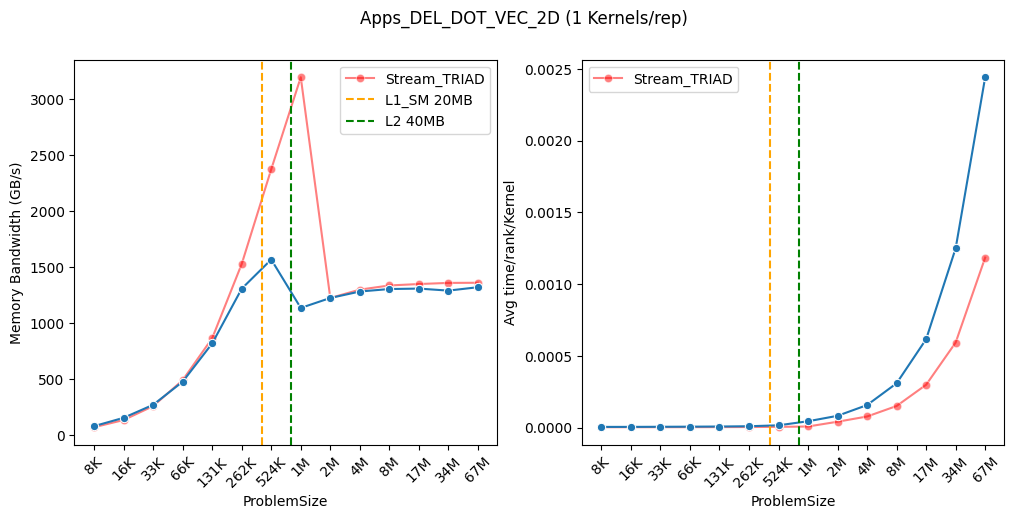

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                                0.824336              0.000507
16384                               0.768666              0.000970
32768                               0.841166              0.001712
65536                               0.902230              0.002933
131072                              0.908861              0.005722
262144                              0.926561              0.010657
524288                              0.943600              0.020517
1048576                             0.942121              0.039972
2097152                             0.999969              0.072899
4194304                             0.948289              0.150432
8388608                             0.954820              0.295458
16777216                            0.947487              0.590738
33554432                            0.949182              1.16

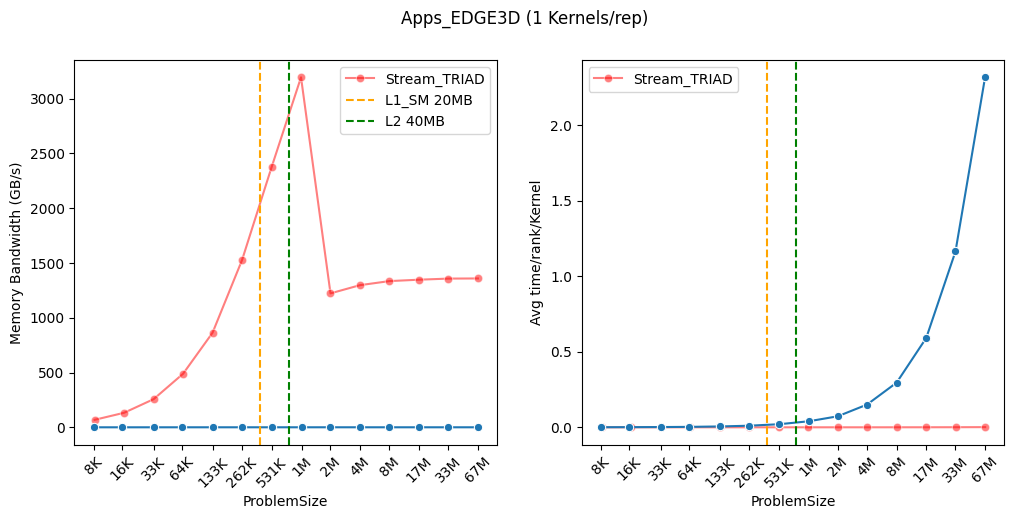

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                               86.104371              0.000003
16384                             164.668671              0.000004
32768                             315.913659              0.000004
65536                             586.019384              0.000004
131072                           1024.500402              0.000005
262144                           1725.131840              0.000005
524288                           1864.090605              0.000010
1048576                          1341.213726              0.000028
2097152                          1294.268175              0.000058
4194304                          1345.136004              0.000112
8388608                          1381.590147              0.000219
16777216                         1398.034253              0.000432
33554432                         1407.502747              0.00

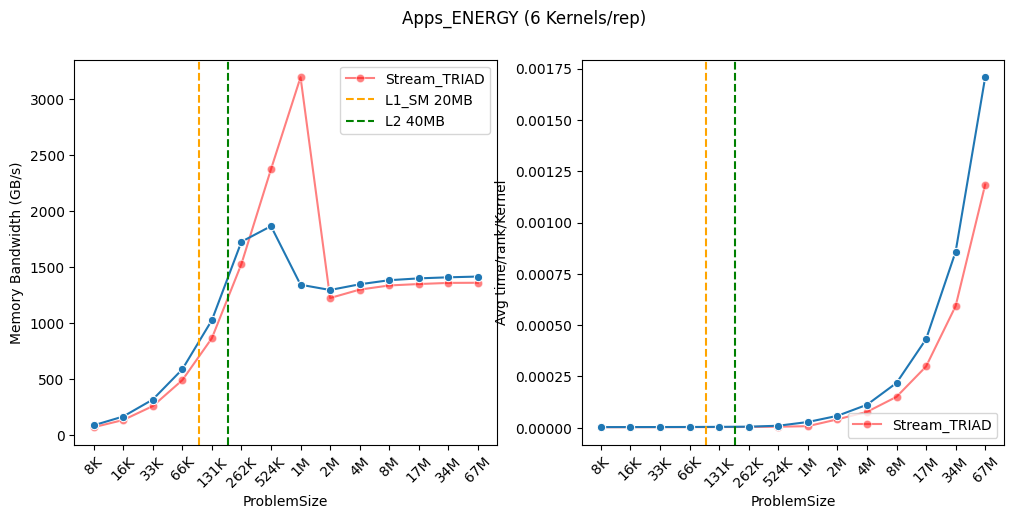

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                               38.187226              0.000003
16384                              74.884336              0.000004
32768                             141.945741              0.000004
65536                             258.260585              0.000004
131072                            453.726235              0.000005
262144                            718.250551              0.000006
524288                           1005.411118              0.000008
1048576                          1288.306453              0.000013
2097152                          1156.116784              0.000029
4194304                          1194.144237              0.000056
8388608                          1234.962273              0.000109
16777216                         1083.111288              0.000248
33554432                         1236.143790              0.00

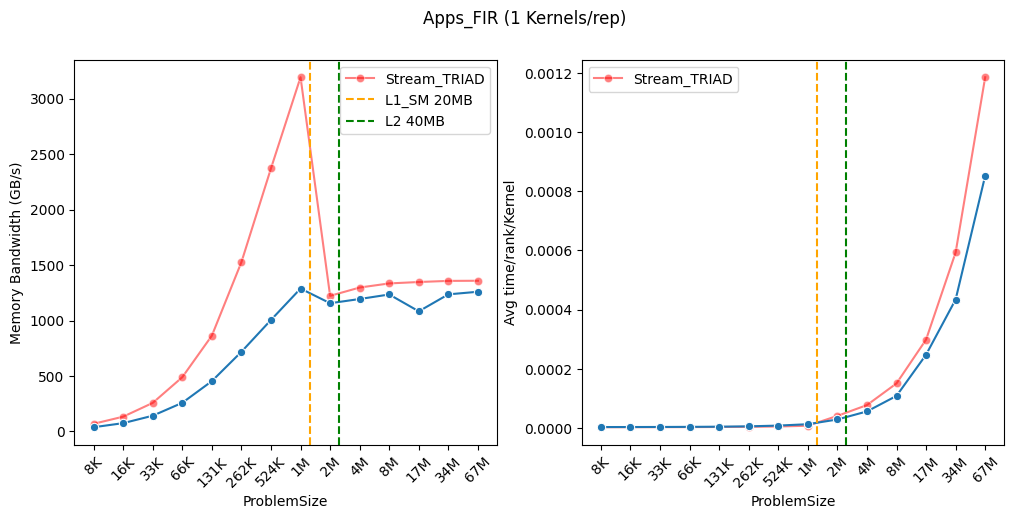

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                                7.581674              0.000017
16384                              14.320864              0.000017
32768                              27.754707              0.000017
65536                              32.706321              0.000029
131072                             46.279444              0.000041
262144                             58.756246              0.000064
524288                             61.608460              0.000121
1048576                            67.055539              0.000223
2097152                            68.704935              0.000435
4194304                            69.412405              0.000861
8388608                            69.896664              0.001710
16777216                           70.159136              0.003408
33554432                           66.516800              0.00

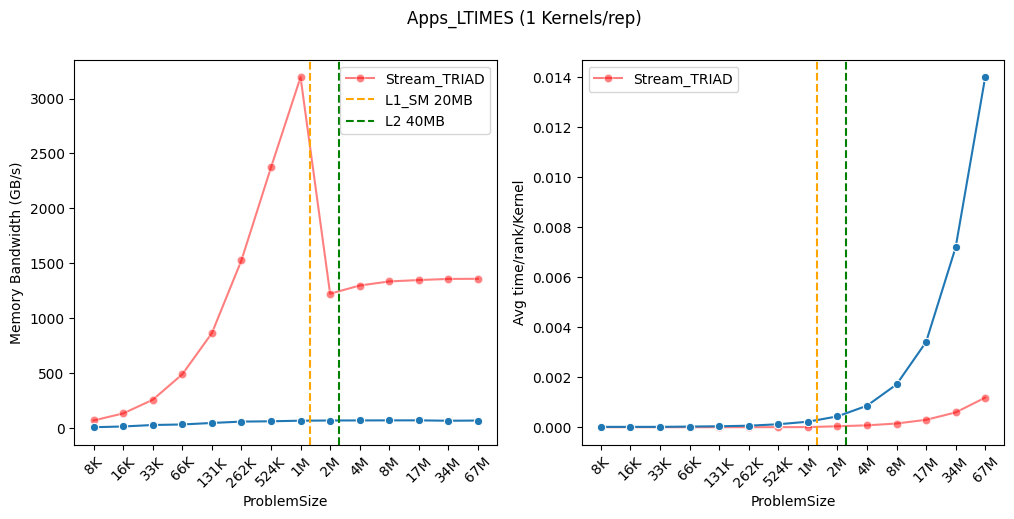

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                                7.756130              0.000017
16384                              14.667936              0.000017
32768                              28.399674              0.000017
65536                              33.187559              0.000029
131072                             46.767893              0.000040
262144                             59.140224              0.000063
524288                             61.836533              0.000121
1048576                            67.256576              0.000222
2097152                            68.783400              0.000435
4194304                            69.451176              0.000861
8388608                            69.875143              0.001711
16777216                           70.120790              0.003410
33554432                           69.899905              0.00

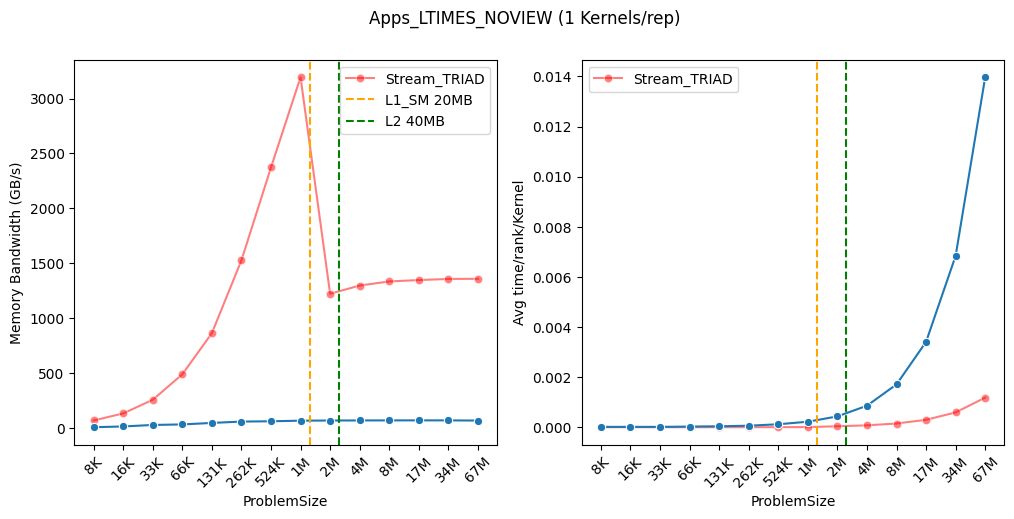

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                              214.156592              0.000006
16384                             391.542852              0.000006
32768                             682.221631              0.000007
65536                            1039.807842              0.000009
131072                           1511.377784              0.000012
262144                           1059.355422              0.000035
524288                           1150.505804              0.000064
1048576                          1166.664631              0.000126
2097152                          1277.666230              0.000227
4194304                          1294.434574              0.000444
8388608                          1291.514996              0.000889
16777216                         1257.318078              0.001828
33554432                         1147.920450              0.00

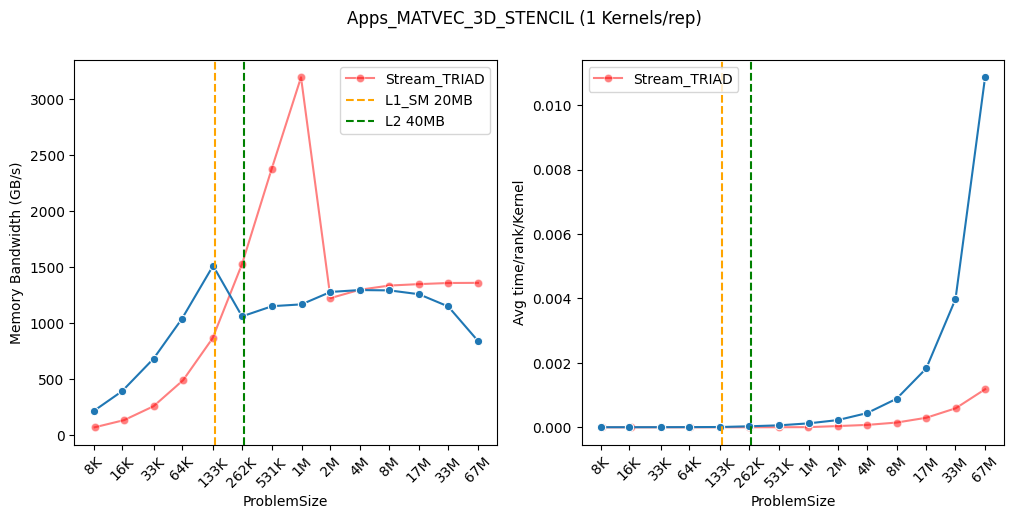

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                               67.361892              0.000003
16384                             129.369497              0.000003
32768                             249.364386              0.000003
65536                             462.379078              0.000003
131072                            840.388386              0.000004
262144                           1366.006464              0.000005
524288                           2007.464947              0.000006
1048576                          1335.684320              0.000019
2097152                          1239.350870              0.000041
4194304                          1302.593637              0.000077
8388608                          1345.173200              0.000150
16777216                         1367.872477              0.000294
33554432                         1379.717284              0.00

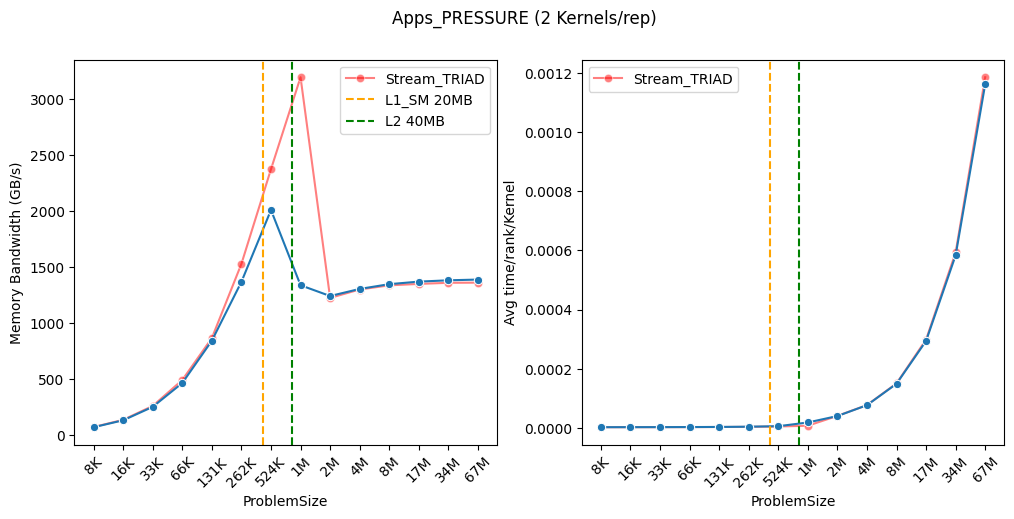

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                               88.450114              0.000005
16384                             150.477948              0.000005
32768                             255.618141              0.000006
65536                             417.727988              0.000006
131072                            705.919273              0.000007
262144                           1045.692017              0.000009
524288                           1407.217168              0.000014
1048576                          1087.496181              0.000035
2097152                          1197.501790              0.000061
4194304                          1242.801211              0.000115
8388608                          1218.905086              0.000231
16777216                         1177.874974              0.000475
33554432                         1057.073976              0.00

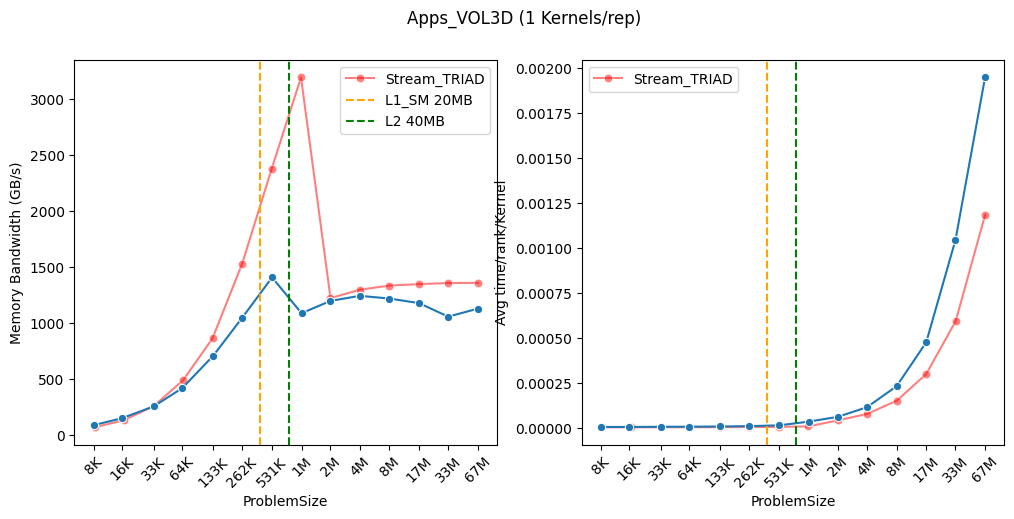

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                               51.647476              0.000004
16384                              98.789262              0.000004
32768                             194.616137              0.000004
65536                             346.920619              0.000005
131072                            629.933602              0.000005
262144                           1030.118802              0.000006
524288                           1499.085736              0.000009
1048576                          1660.873673              0.000015
2097152                          1155.579885              0.000044
4194304                          1236.874317              0.000081
8388608                          1282.250835              0.000157
16777216                         1306.757165              0.000309
33554432                         1262.273054              0.00

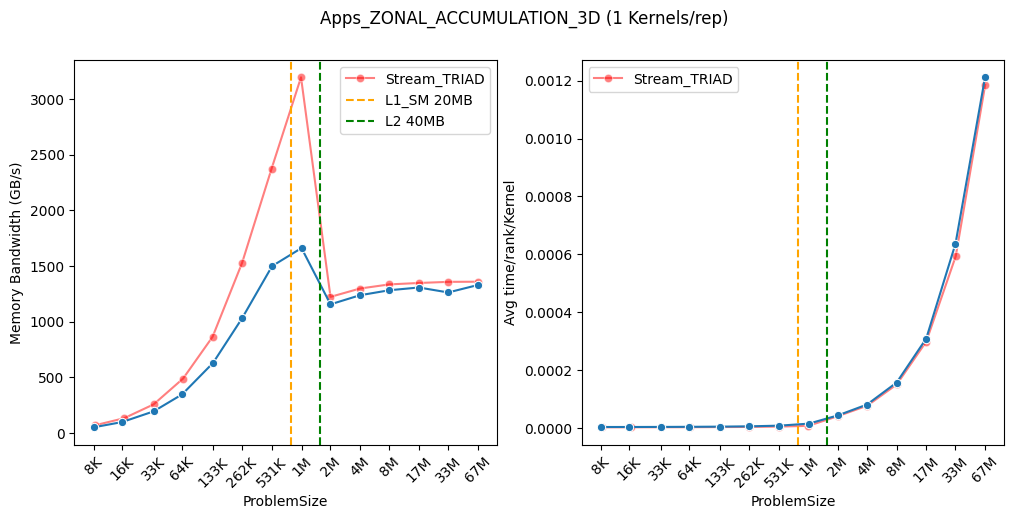

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                              182.806701              0.000010
16384                             377.271931              0.000009
32768                             594.524572              0.000012
65536                             645.810690              0.000022
131072                            458.350845              0.000062
262144                            475.716375              0.000119
524288                            502.914289              0.000225
1048576                           517.427268              0.000438
2097152                           527.515551              0.000859
4194304                           529.817449              0.001710
8388608                           531.795861              0.003407
16777216                          532.624026              0.006804
33554432                          532.788554              0.01

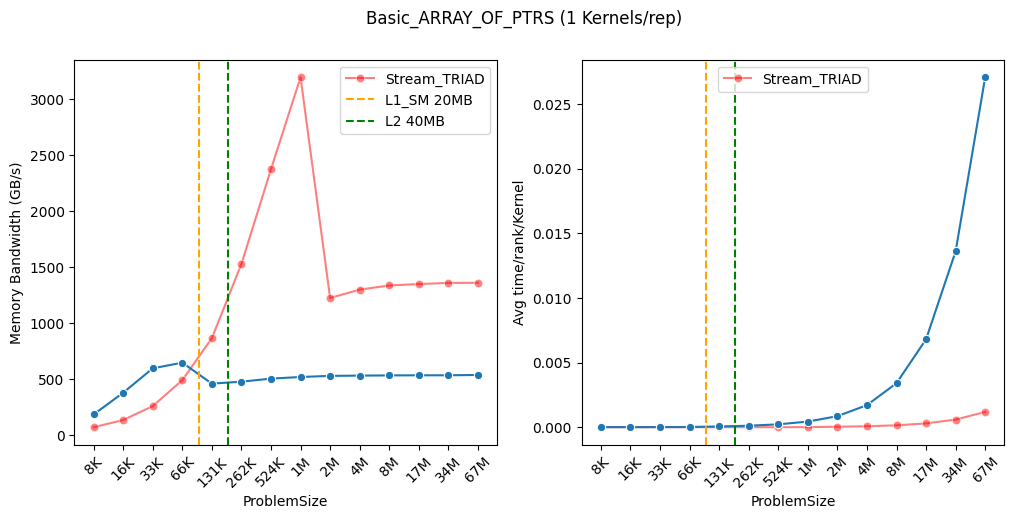

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                              149.405130              0.000007
16384                             314.440740              0.000007
32768                             638.160161              0.000007
65536                            1170.332274              0.000007
131072                           1877.721917              0.000009
262144                           1207.806294              0.000028
524288                           1192.878224              0.000056
1048576                          1264.815795              0.000106
2097152                          1325.825675              0.000202
4194304                          1348.932477              0.000398
8388608                          1353.826500              0.000793
16777216                         1370.857450              0.001567
33554432                         1363.718687              0.00

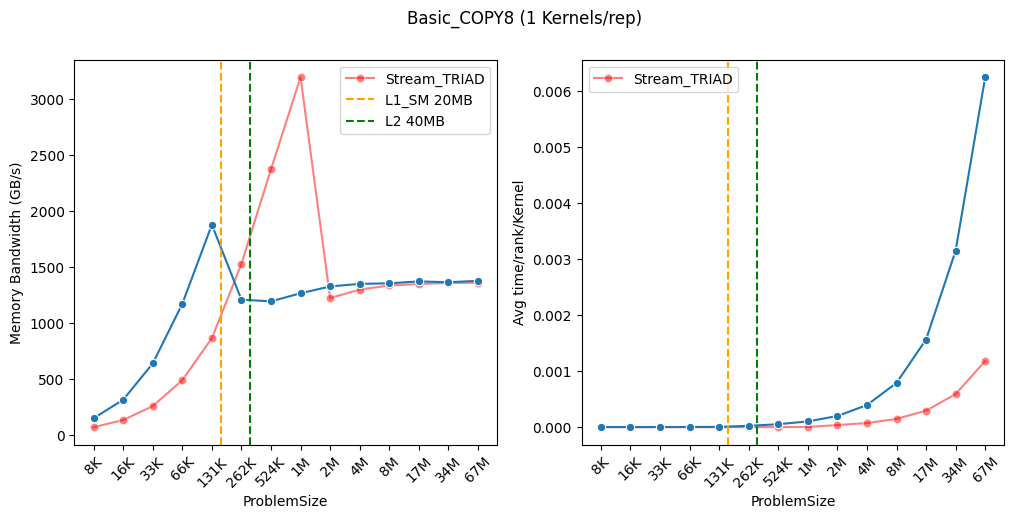

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                               59.509994              0.000003
16384                             126.926496              0.000003
32768                             261.065625              0.000003
65536                             502.069799              0.000003
131072                            892.710892              0.000004
262144                           1603.982978              0.000004
524288                           2383.518730              0.000005
1048576                          3318.528675              0.000008
2097152                          1518.355804              0.000033
4194304                          1286.604921              0.000078
8388608                          1335.549310              0.000151
16777216                         1355.004950              0.000297
33554432                         1355.278597              0.00

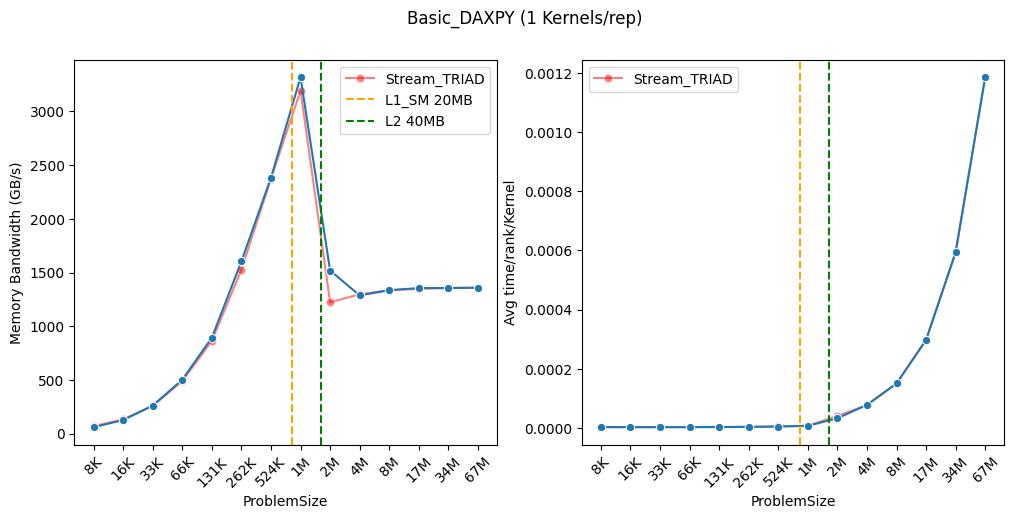

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                               19.501962              0.000003
16384                              40.681989              0.000003
32768                              84.227670              0.000003
65536                             161.105991              0.000003
131072                            308.202904              0.000003
262144                            505.162064              0.000004
524288                            773.821252              0.000005
1048576                          1084.016545              0.000008
2097152                          1128.990449              0.000015
4194304                           422.426908              0.000079
8388608                           436.530280              0.000154
16777216                          443.796334              0.000302
33554432                          447.665041              0.00

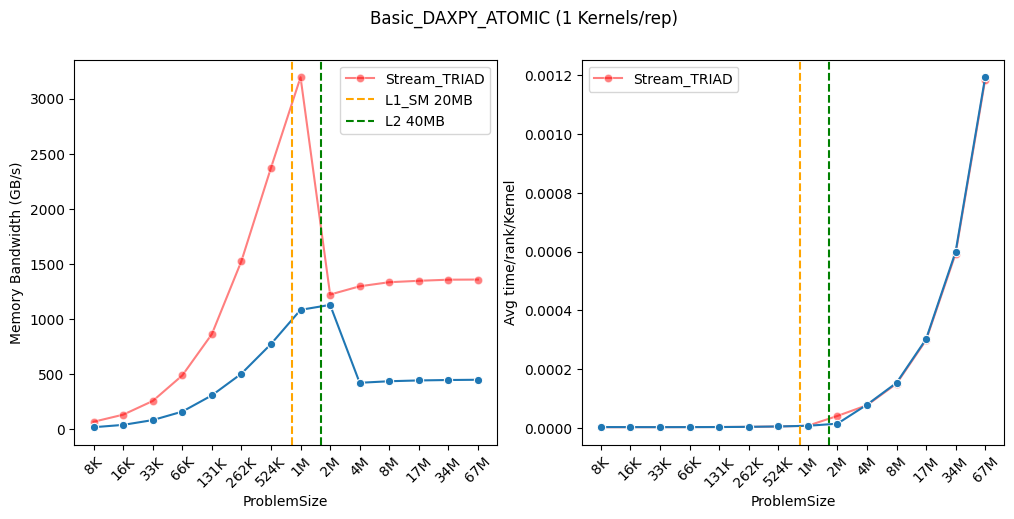

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                               75.255038              0.000004
16384                             160.429841              0.000004
32768                             308.500361              0.000004
65536                             556.171193              0.000005
131072                            955.714142              0.000005
262144                           1341.308923              0.000008
524288                           1799.199555              0.000012
1048576                          1200.692386              0.000035
2097152                          1286.050909              0.000065
4194304                          1345.540846              0.000125
8388608                          1374.056273              0.000244
16777216                         1385.511728              0.000484
33554432                         1358.340803              0.00

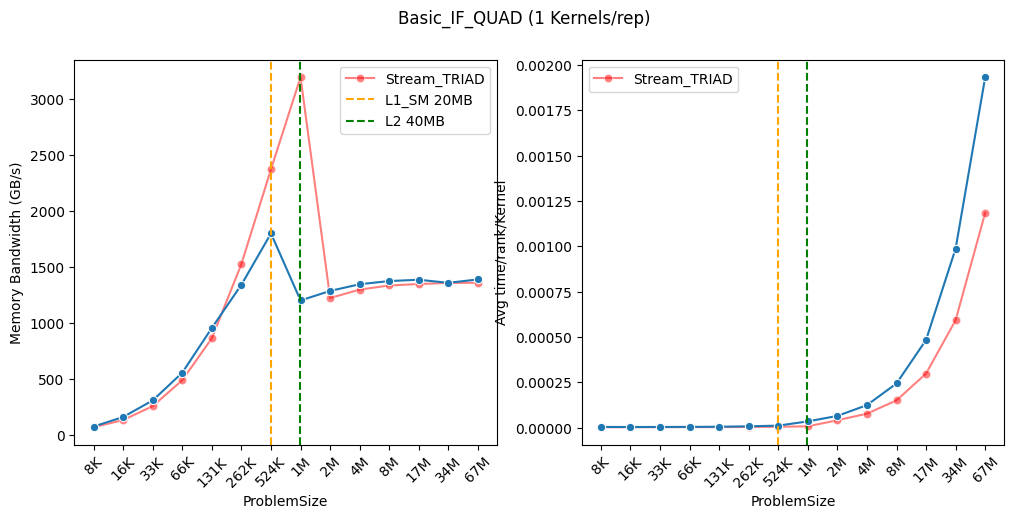

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                               93.451664              0.000004
16384                             198.591171              0.000003
32768                             394.250830              0.000003
65536                             737.153937              0.000004
131072                           1235.085815              0.000004
262144                           1777.601773              0.000006
524288                           2441.632080              0.000009
1048576                          1331.590093              0.000031
2097152                          1223.498594              0.000069
4194304                          1263.755244              0.000133
8388608                          1282.927432              0.000262
16777216                         1292.873062              0.000519
33554432                         1298.094741              0.00

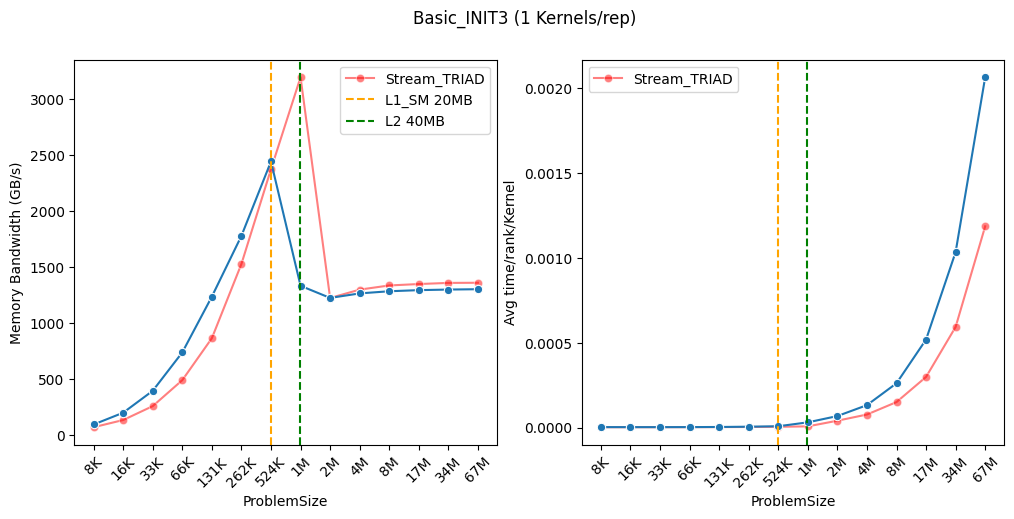

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                               21.423804              0.000003
16384                              46.023429              0.000003
32768                              93.636475              0.000003
65536                             183.098021              0.000003
131072                            351.884764              0.000003
262144                            622.568978              0.000003
524288                            984.850079              0.000004
1048576                          1415.532916              0.000006
2097152                          1855.799556              0.000009
4194304                          1379.332798              0.000024
8388608                          1463.107460              0.000046
16777216                         1479.226162              0.000091
33554432                         1519.037784              0.00

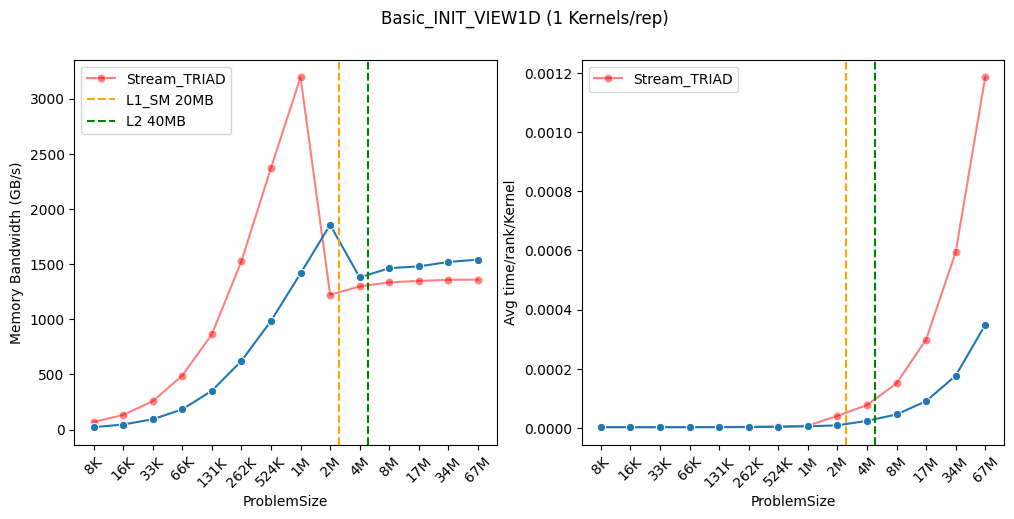

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                               22.784067              0.000003
16384                              48.047794              0.000003
32768                              93.799307              0.000003
65536                             183.331482              0.000003
131072                            350.342732              0.000003
262144                            626.340248              0.000003
524288                            983.429300              0.000004
1048576                          1407.821265              0.000006
2097152                          1849.309270              0.000009
4194304                          1378.029913              0.000024
8388608                          1462.392514              0.000046
16777216                         1506.055731              0.000089
33554432                         1514.015109              0.00

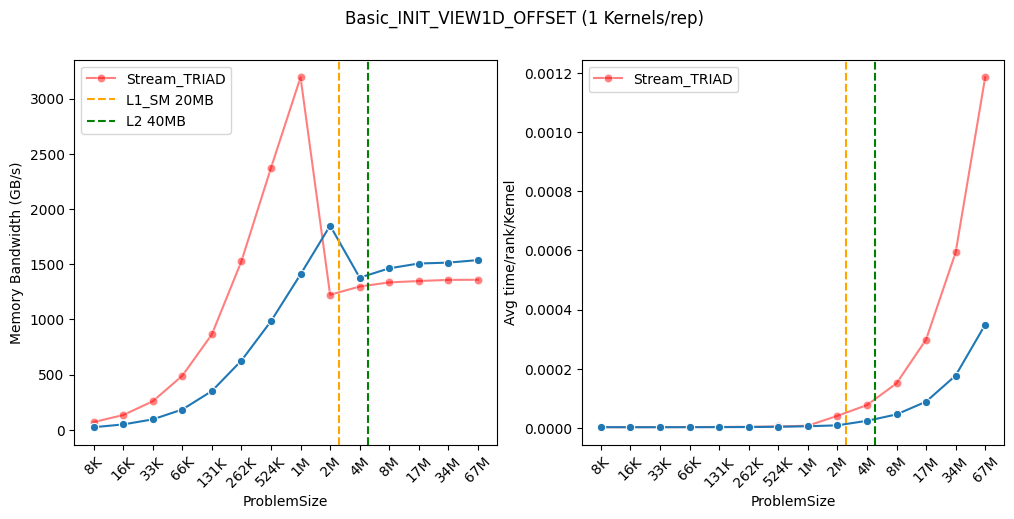

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                                8.049220              0.000024
16384                              15.710305              0.000025
32768                              25.152441              0.000031
65536                              38.015782              0.000041
131072                             45.495036              0.000069
262144                             43.122072              0.000146
524288                             33.167892              0.000379
1048576                            26.771979              0.000940
2097152                            18.761983              0.002682
4194304                            13.267733              0.007587
8388608                             8.973866              0.022430
16777216                            6.273507              0.064183
33554432                            4.232375              0.19

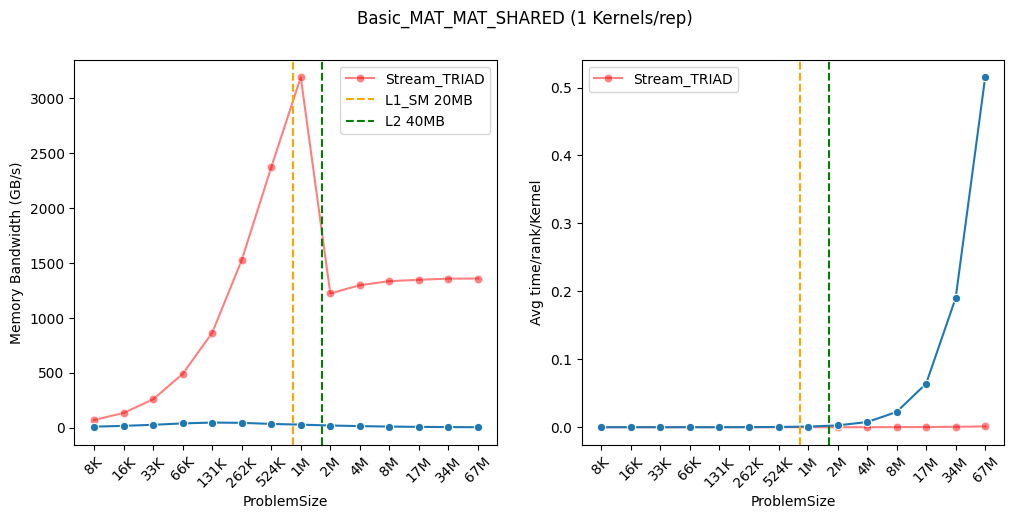

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                               95.335091              0.000003
16384                             203.082574              0.000003
32768                             379.306610              0.000003
65536                             686.350490              0.000004
131072                           1203.985325              0.000004
262144                           1717.614221              0.000006
524288                           2407.755600              0.000009
1048576                          1334.168670              0.000031
2097152                          1222.947176              0.000069
4194304                          1262.877464              0.000133
8388608                          1281.639733              0.000262
16777216                         1291.149336              0.000520
33554432                         1297.034278              0.00

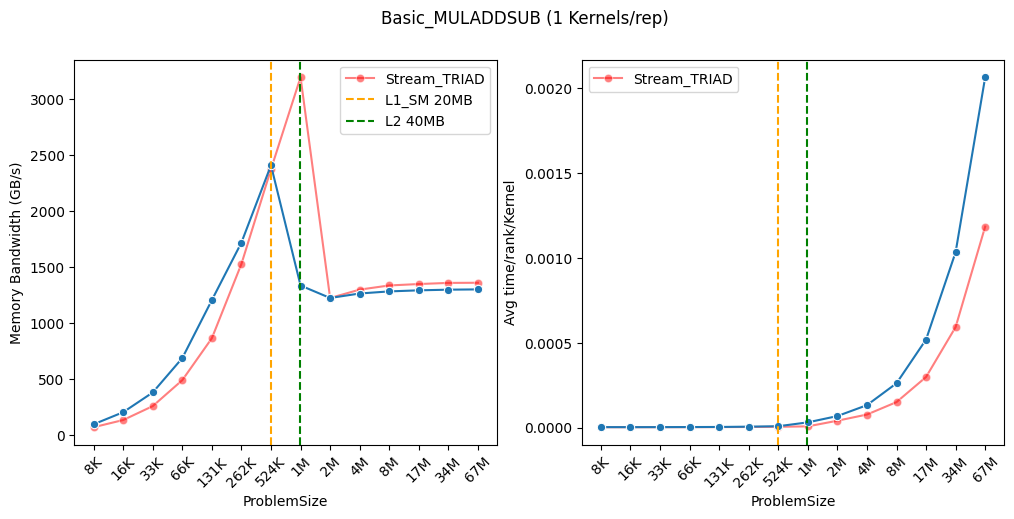

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                               21.635422              0.000003
16384                              41.924699              0.000003
32768                              88.668145              0.000003
65536                             160.439403              0.000003
131072                            314.250281              0.000003
262144                            592.187078              0.000004
524288                            811.801601              0.000005
1048576                          1102.202546              0.000008
2097152                          1625.644116              0.000010
4194304                          1400.035561              0.000024
8388608                          1464.100086              0.000046
16777216                         1399.936333              0.000096
33554432                         1421.438955              0.00

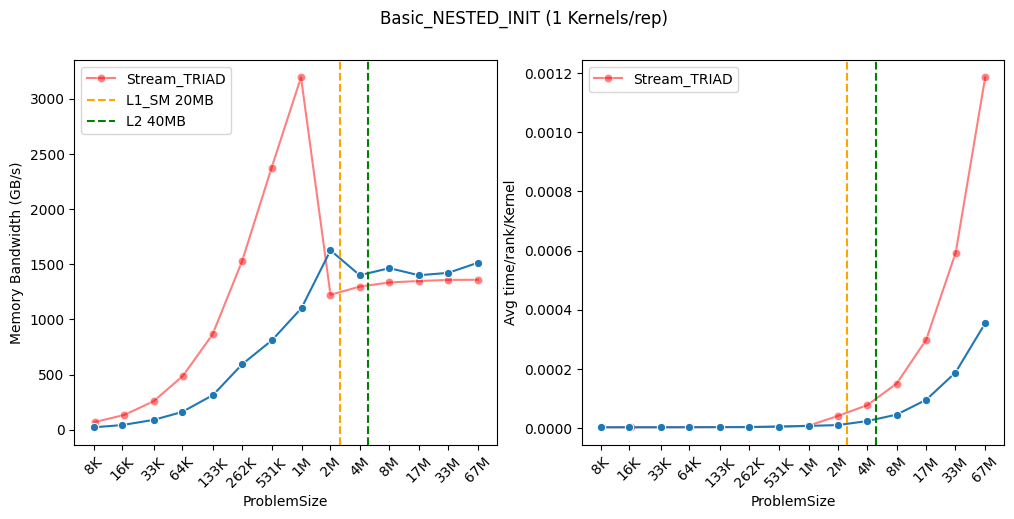

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                                0.402300              0.000005
16384                               0.603833              0.000005
32768                               0.971496              0.000005
65536                               1.465342              0.000005
131072                              2.337080              0.000005
262144                              3.470672              0.000006
524288                              5.172761              0.000006
1048576                             7.467498              0.000007
2097152                            10.389686              0.000007
4194304                            12.690700              0.000010
8388608                            16.124689              0.000012
16777216                           20.483175              0.000015
33554432                           21.889608              0.00

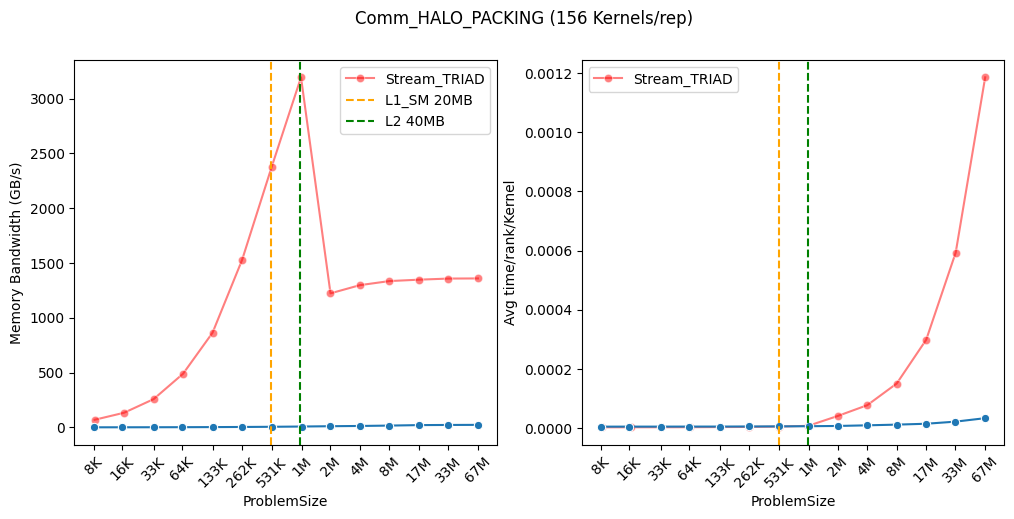

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                              305.977405              0.000004
16384                             595.212443              0.000004
32768                            1087.751817              0.000005
65536                            1803.425865              0.000006
131072                           2405.789607              0.000009
262144                           1767.088002              0.000024
524288                            543.073780              0.000154
1048576                           550.349586              0.000305
2097152                           565.836141              0.000593
4194304                           561.316403              0.001196
8388608                           568.450682              0.002361
16777216                          577.191232              0.004651
33554432                          554.086063              0.00

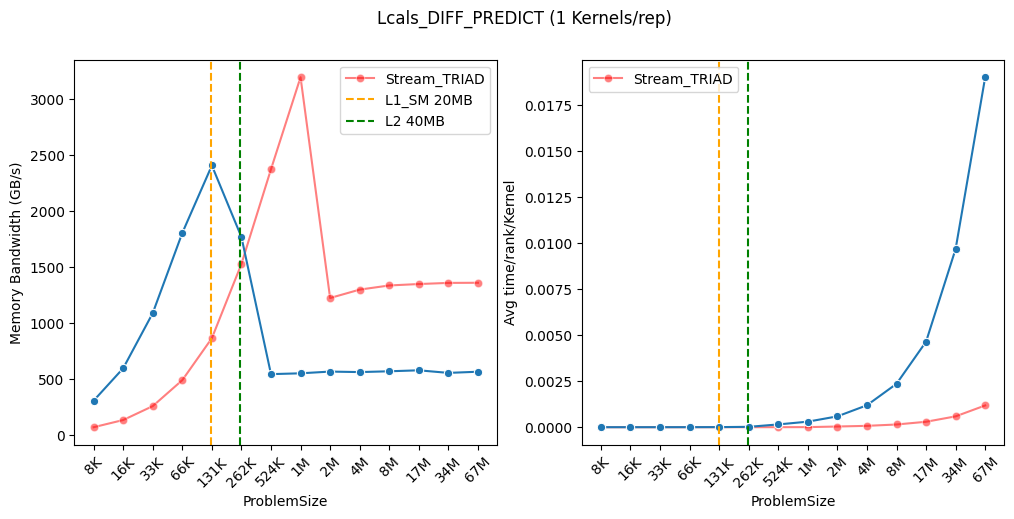

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                               86.861436              0.000003
16384                             171.567935              0.000003
32768                             313.642250              0.000003
65536                             563.604388              0.000004
131072                           1009.126105              0.000004
262144                           1735.955963              0.000005
524288                           2700.470582              0.000006
1048576                          1348.338532              0.000025
2097152                          1250.683964              0.000054
4194304                          1302.809355              0.000103
8388608                          1345.061968              0.000200
16777216                         1366.430688              0.000393
33554432                         1371.329340              0.00

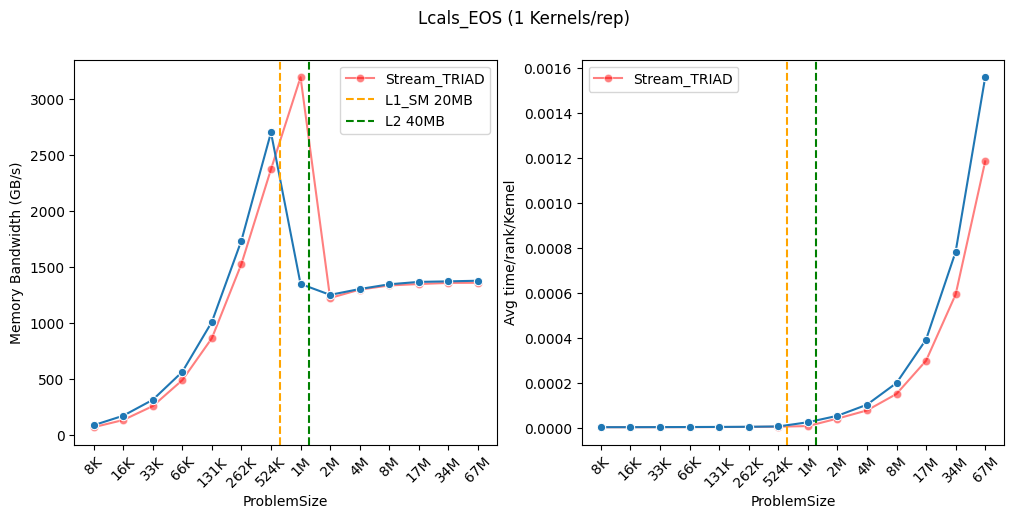

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                               49.136494              0.000003
16384                              96.201121              0.000003
32768                             182.078074              0.000003
65536                             353.494682              0.000003
131072                            650.075356              0.000003
262144                           1123.149578              0.000004
524288                           1733.826188              0.000005
1048576                          2461.007205              0.000007
2097152                          1299.596539              0.000026
4194304                          1278.473744              0.000052
8388608                          1333.114157              0.000101
16777216                         1362.038522              0.000197
33554432                         1376.080241              0.00

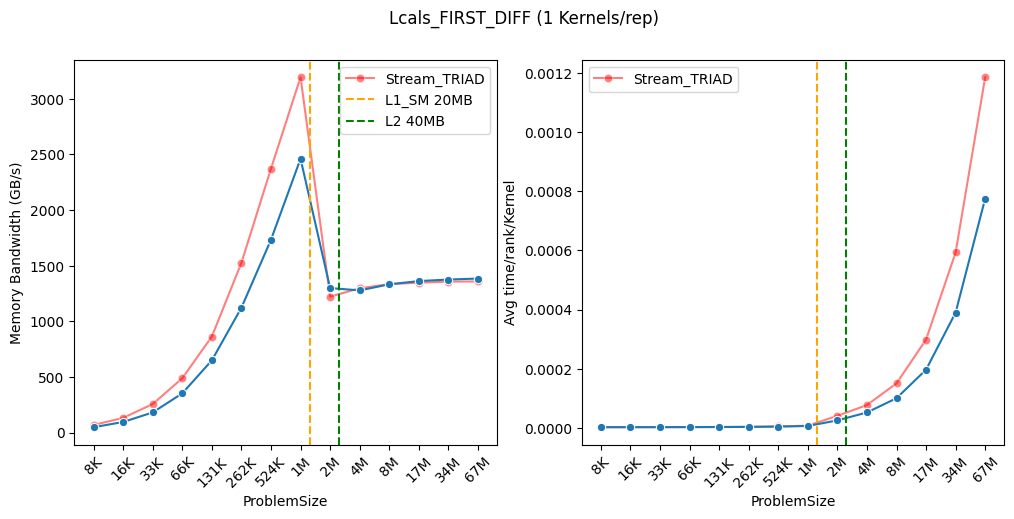

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                               49.027889              0.000003
16384                              95.954750              0.000003
32768                             182.137415              0.000003
65536                             353.308366              0.000003
131072                            646.301062              0.000003
262144                           1059.704698              0.000004
524288                           1628.605493              0.000005
1048576                          2306.761475              0.000007
2097152                          1276.150524              0.000026
4194304                          1275.263438              0.000053
8388608                          1331.634121              0.000101
16777216                         1360.343304              0.000197
33554432                         1372.556188              0.00

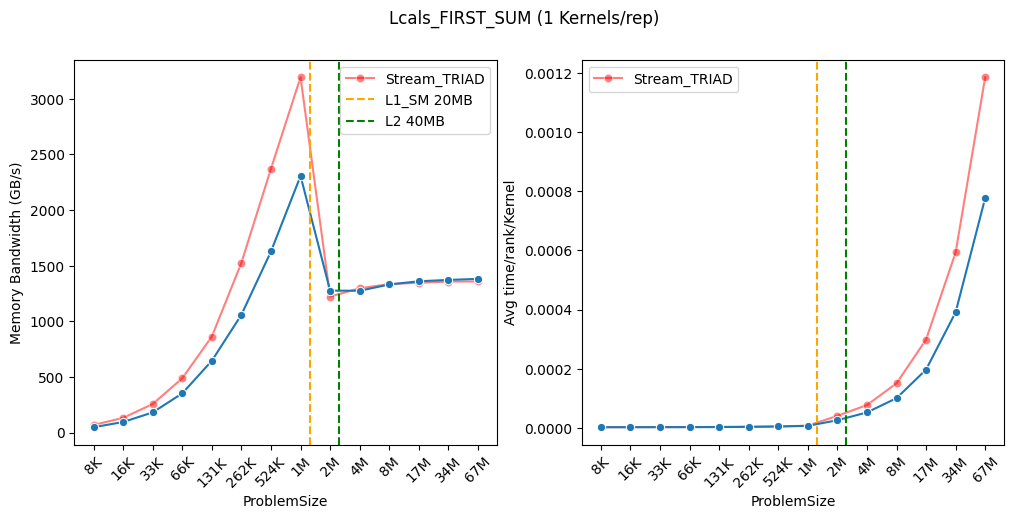

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                              108.825030              0.000003
16384                             214.443245              0.000003
32768                             398.282552              0.000003
65536                             736.749862              0.000004
131072                           1289.700462              0.000004
262144                           1996.506318              0.000005
524288                           2900.571857              0.000007
1048576                          2610.400401              0.000016
2097152                          1810.384716              0.000046
4194304                          1584.377891              0.000106
8388608                          1480.835514              0.000227
16777216                         1437.141592              0.000467
33554432                         1411.965935              0.00

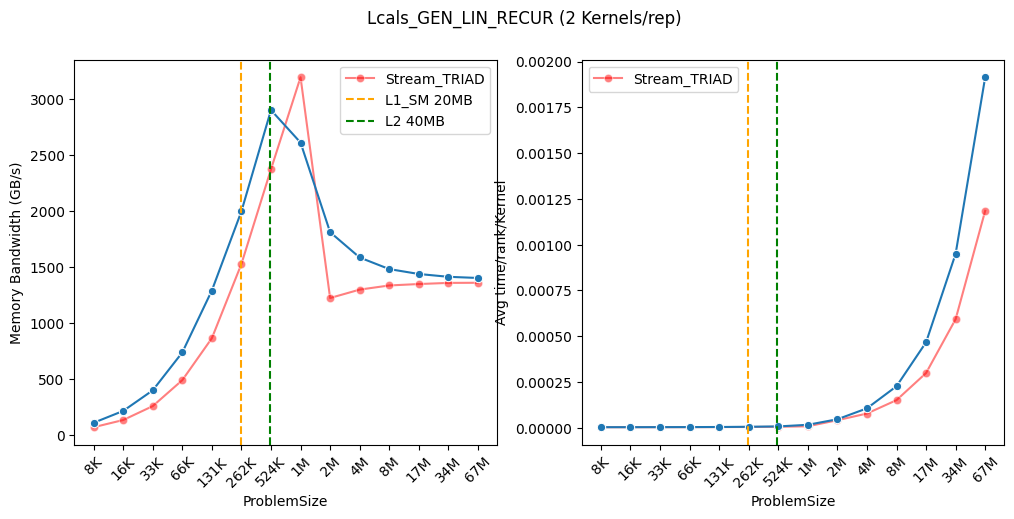

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                               68.497007              0.000003
16384                             133.715094              0.000003
32768                             253.979860              0.000003
65536                             479.955522              0.000003
131072                            869.428949              0.000004
262144                           1548.390368              0.000004
524288                           2372.658533              0.000005
1048576                          3006.793594              0.000008
2097152                          1219.883197              0.000041
4194304                          1298.055894              0.000078
8388608                          1336.738984              0.000151
16777216                         1350.433215              0.000298
33554432                         1356.191093              0.00

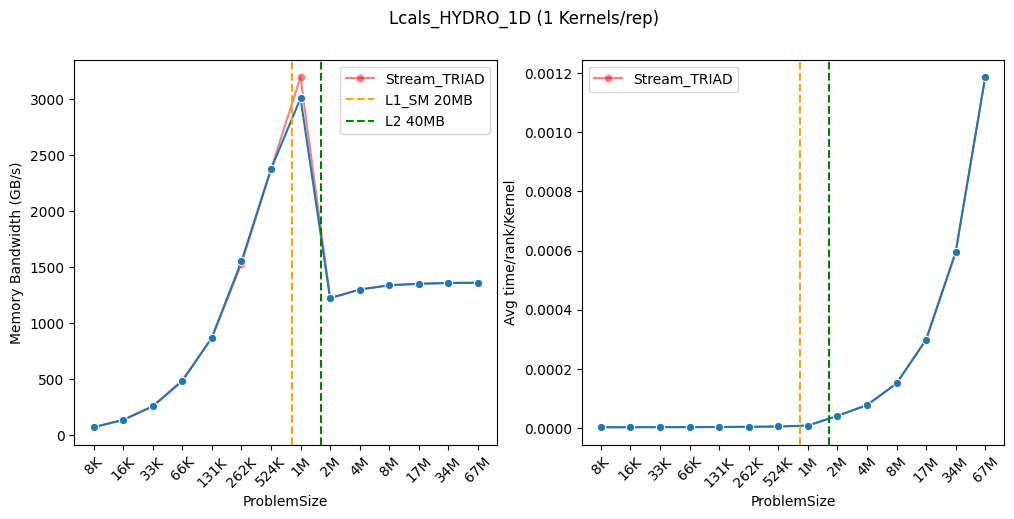

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                               84.128321              0.000005
16384                             169.839374              0.000005
32768                             307.808592              0.000005
65536                             563.304238              0.000006
131072                            976.409223              0.000006
262144                           1456.314291              0.000009
524288                           1256.646869              0.000020
1048576                          1047.372830              0.000048
2097152                          1122.813683              0.000089
4194304                          1168.951320              0.000172
8388608                          1188.652097              0.000338
16777216                         1191.790274              0.000675
33554432                         1200.432001              0.00

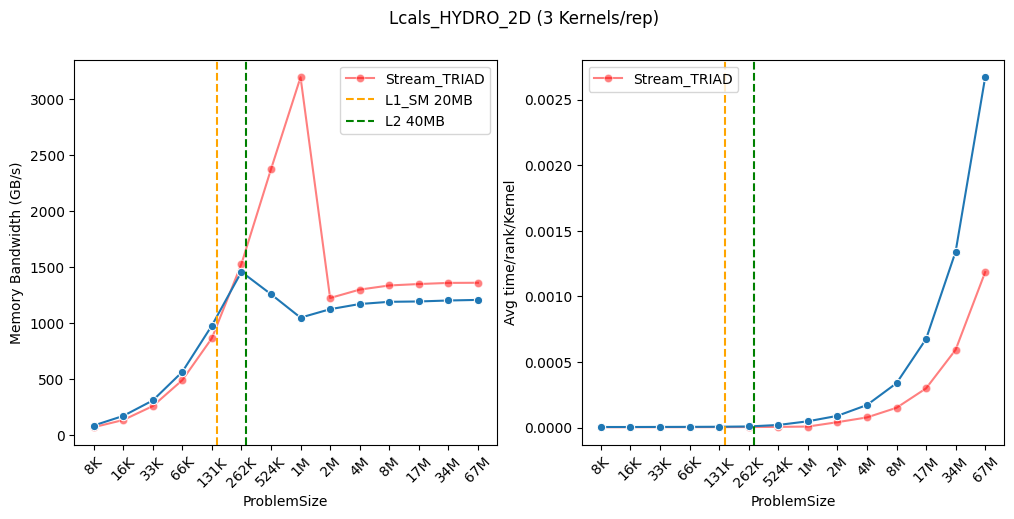

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                              216.794559              0.000003
16384                             424.609087              0.000003
32768                             719.515071              0.000004
65536                            1278.777731              0.000005
131072                           2061.094592              0.000006
262144                           2988.815579              0.000008
524288                           1208.939602              0.000038
1048576                          1308.690355              0.000071
2097152                          1364.621796              0.000135
4194304                          1396.160448              0.000264
8388608                          1411.750340              0.000523
16777216                         1418.161210              0.001041
33554432                         1423.374984              0.00

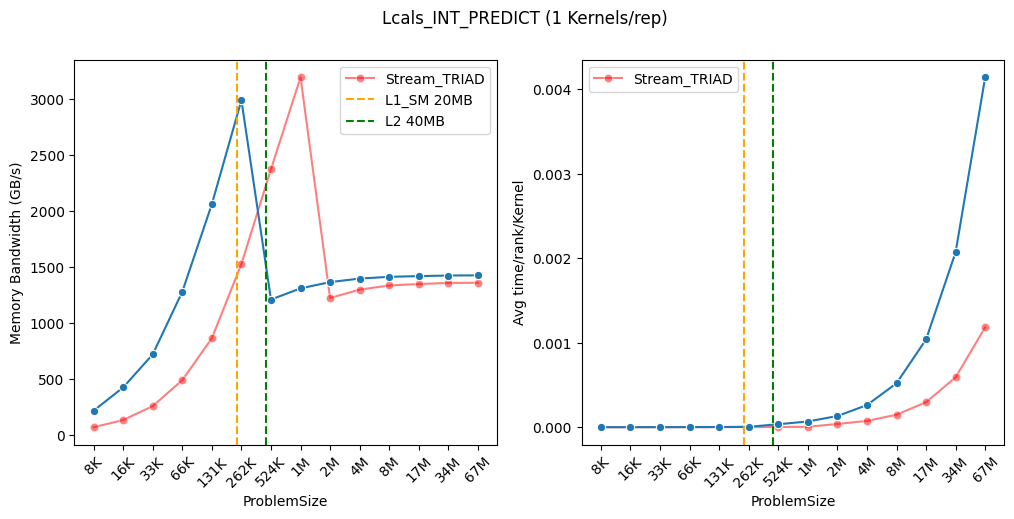

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                               64.461098              0.000005
16384                             127.088438              0.000005
32768                             243.196105              0.000005
65536                             446.775034              0.000006
131072                            795.139091              0.000007
262144                           1350.073286              0.000008
524288                           2070.142268              0.000010
1048576                          1149.995015              0.000036
2097152                          1252.340880              0.000067
4194304                          1325.338105              0.000127
8388608                          1352.938567              0.000248
16777216                         1369.543869              0.000490
33554432                         1378.895328              0.00

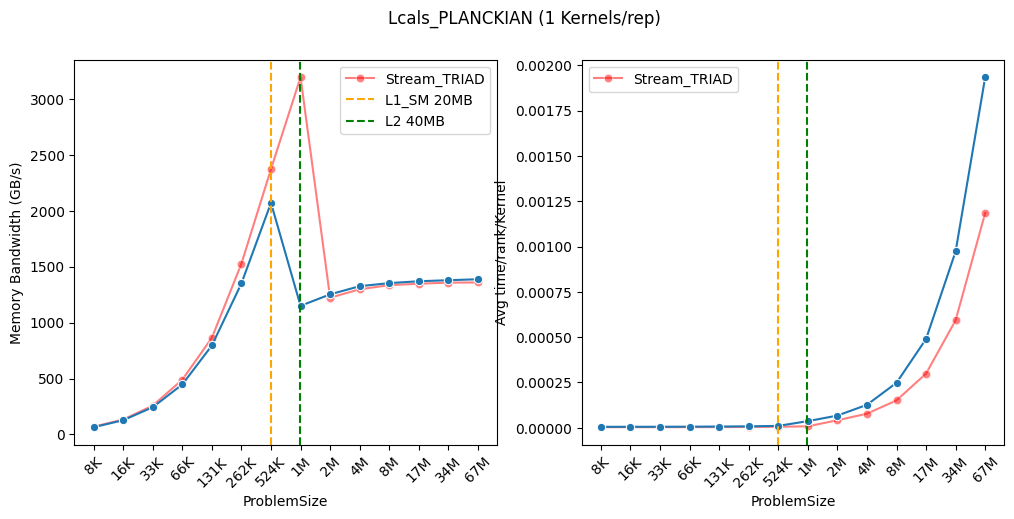

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                               90.084220              0.000003
16384                             177.476159              0.000003
32768                             331.400803              0.000003
65536                             614.558950              0.000003
131072                           1099.541236              0.000004
262144                           1845.633287              0.000005
524288                           2709.683421              0.000006
1048576                          1393.871179              0.000024
2097152                          1257.446725              0.000053
4194304                          1324.278234              0.000101
8388608                          1357.330567              0.000198
16777216                         1374.797316              0.000391
33554432                         1384.631474              0.00

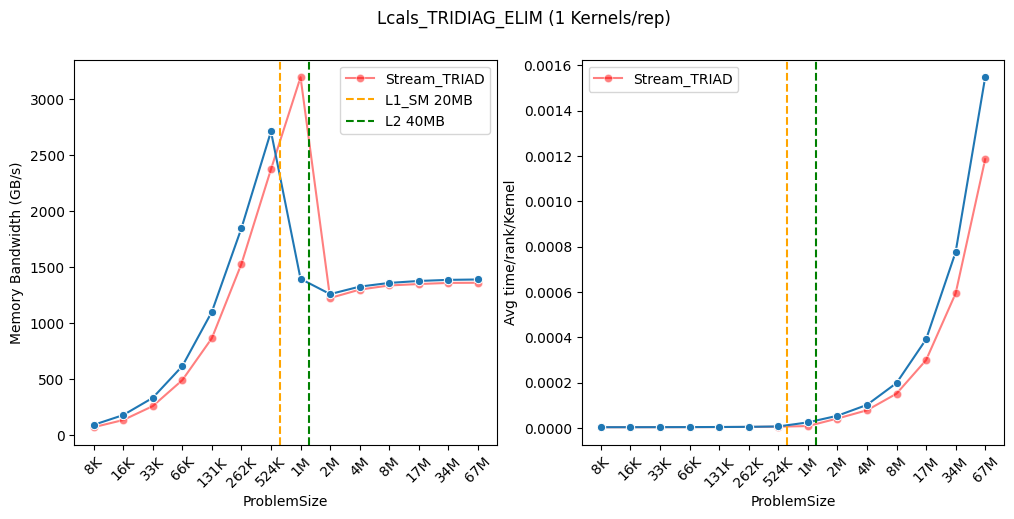

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                                3.597463              0.000056
16384                               6.955053              0.000059
32768                              12.990953              0.000063
65536                              22.367134              0.000073
131072                             27.599160              0.000118
262144                             34.029462              0.000192
524288                             29.152875              0.000449
1048576                            22.815590              0.001147
2097152                            16.500594              0.003171
4194304                            11.264415              0.009293
8388608                             7.396031              0.028302
16777216                            5.012065              0.083547
33554432                            3.107858              0.26

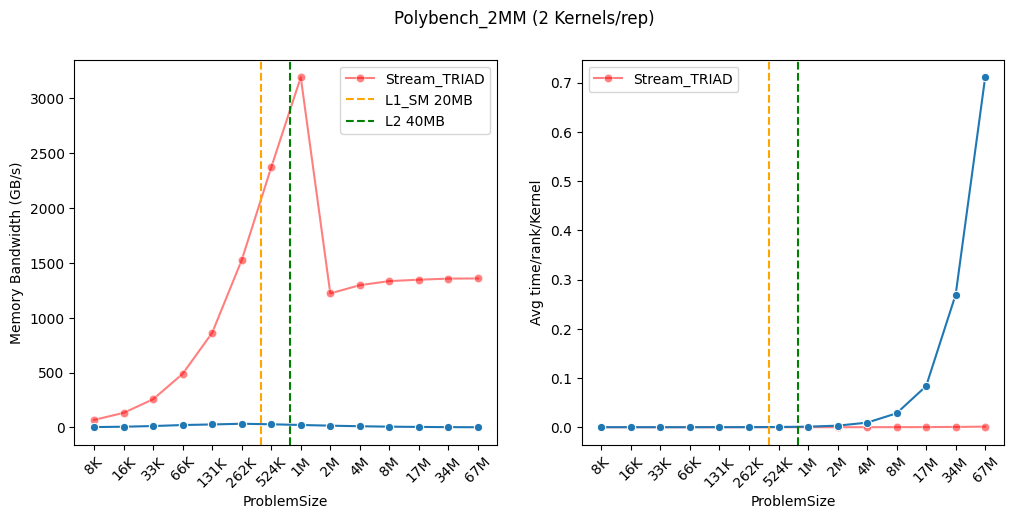

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                                3.795419              0.000053
16384                               7.237250              0.000057
32768                              13.732334              0.000060
65536                              23.308292              0.000071
131072                             28.230414              0.000117
262144                             34.441878              0.000191
524288                             28.969243              0.000454
1048576                            23.234194              0.001133
2097152                            16.474815              0.003196
4194304                            11.425503              0.009221
8388608                             7.614892              0.027664
16777216                            5.088403              0.082819
33554432                            3.175374              0.26

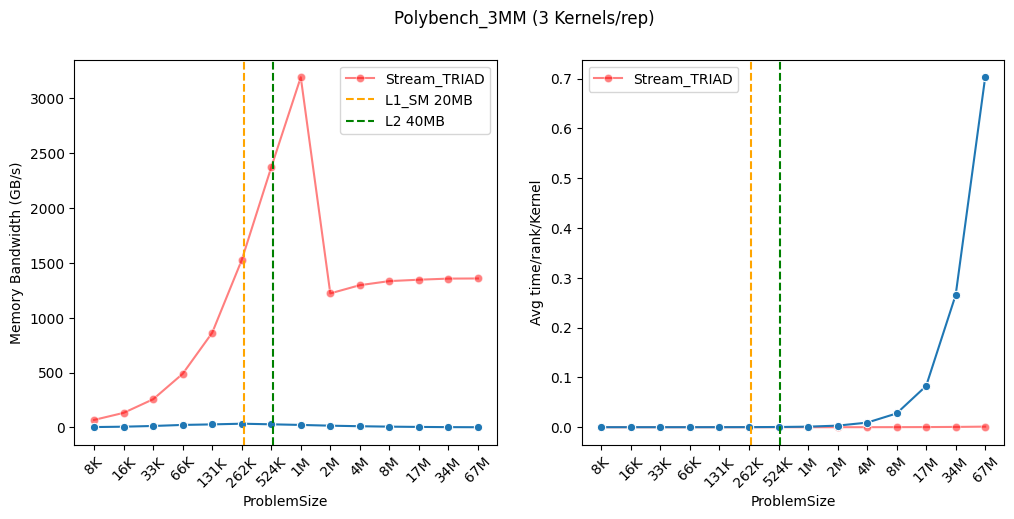

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                                1.423155              0.000070
16384                               2.022600              0.000099
32768                               2.205995              0.000180
65536                               2.569923              0.000308
131072                              3.104014              0.000509
262144                              5.065986              0.000623
524288                              6.463285              0.000976
1048576                             9.113783              0.001383
2097152                            10.710310              0.002352
4194304                            14.958260              0.003368
8388608                            19.609432              0.005136
16777216                           27.763779              0.007255
33554432                           33.316052              0.01

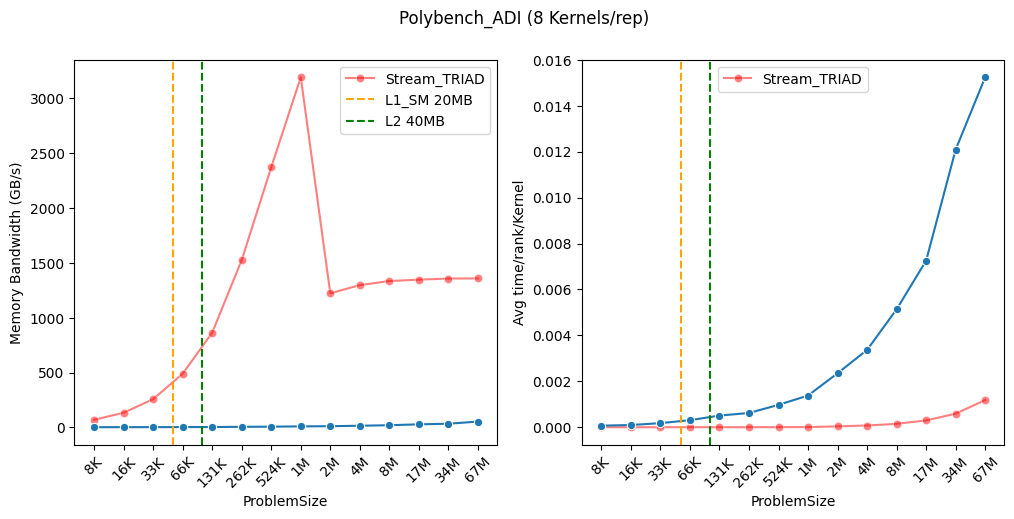

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                                7.135545              0.000009
16384                               9.061634              0.000015
32768                              16.327900              0.000016
65536                              14.056209              0.000038
131072                             28.605659              0.000037
262144                             28.337506              0.000074
524288                             53.338525              0.000079
1048576                            57.990151              0.000145
2097152                           100.640985              0.000167
4194304                            92.580233              0.000363
8388608                           128.467211              0.000523
16777216                          182.299491              0.000737
33554432                          264.278512              0.00

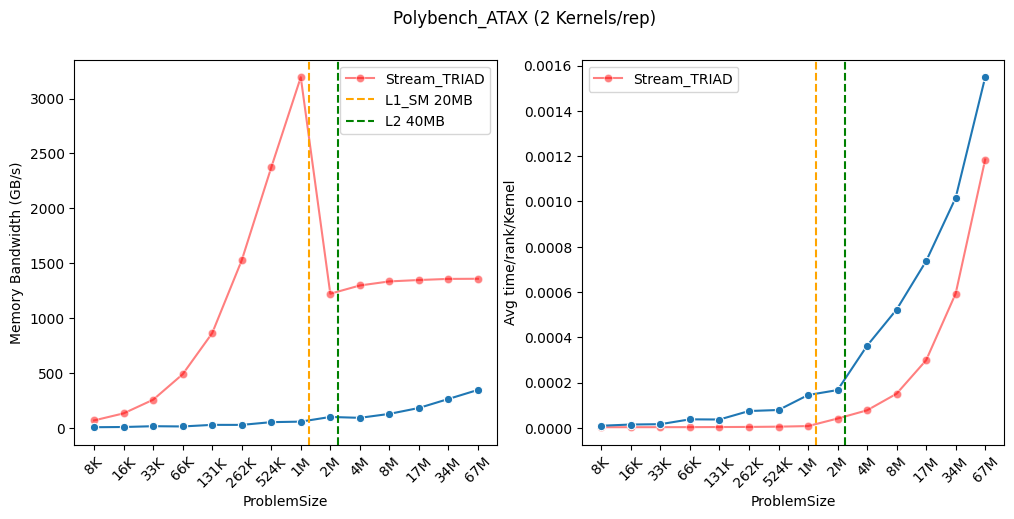

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                                1.332289              0.000003
16384                               2.549206              0.000003
32768                               4.847368              0.000003
65536                               8.864575              0.000004
131072                             16.417935              0.000004
262144                             27.978831              0.000005
524288                             44.139951              0.000006
1048576                            52.981711              0.000010
2097152                            28.980250              0.000036
4194304                            30.833800              0.000068
8388608                            32.064527              0.000131
16777216                           32.640210              0.000257
33554432                           32.917041              0.00

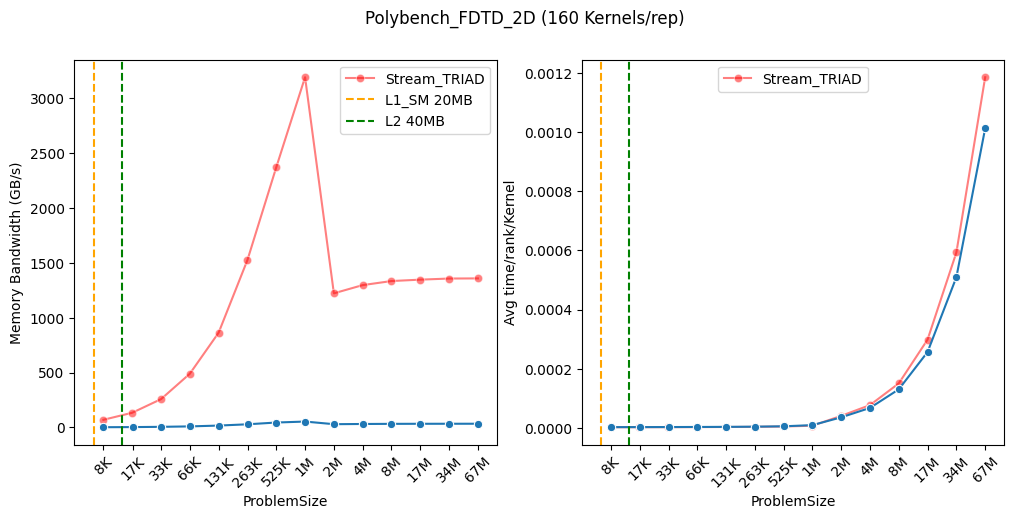

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                                0.441806              0.000293
16384                               0.637953              0.000411
32768                               0.835333              0.000628
65536                               1.119796              0.000936
131072                              1.488775              0.001408
262144                              1.910379              0.002196
524288                              2.017761              0.004156
1048576                             2.119870              0.007914
2097152                             0.825092              0.040659
4194304                             0.607622              0.110445
8388608                             0.442719              0.303102
16777216                            0.320861              0.836612
33554432                            0.226671              2.36

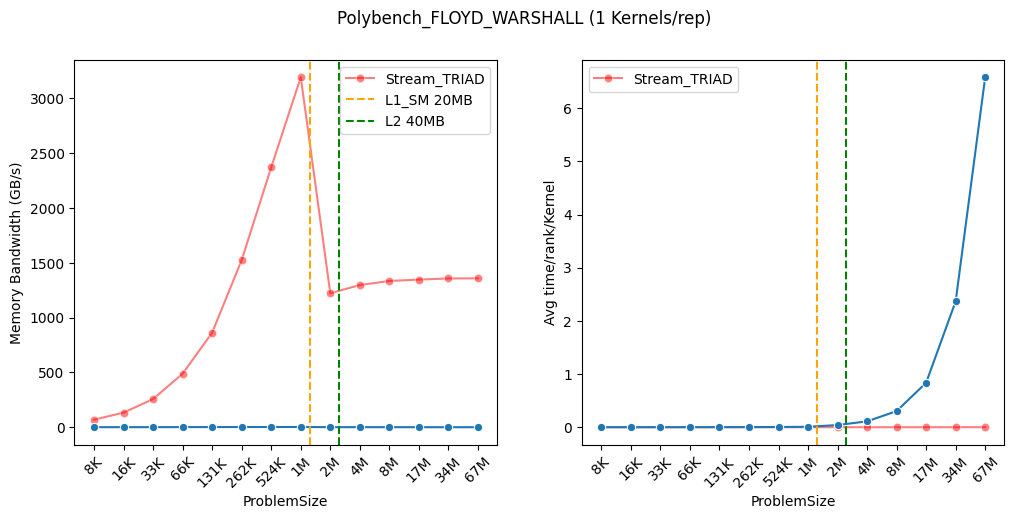

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                                2.059313              0.000004
16384                               3.852438              0.000004
32768                               7.378628              0.000004
65536                              12.299517              0.000004
131072                             22.285748              0.000005
262144                             38.311240              0.000006
524288                             51.135281              0.000009
1048576                            61.359776              0.000014
2097152                            56.325741              0.000030
4194304                            58.731124              0.000058
8388608                            61.368750              0.000111
16777216                           63.108486              0.000215
33554432                           61.577324              0.00

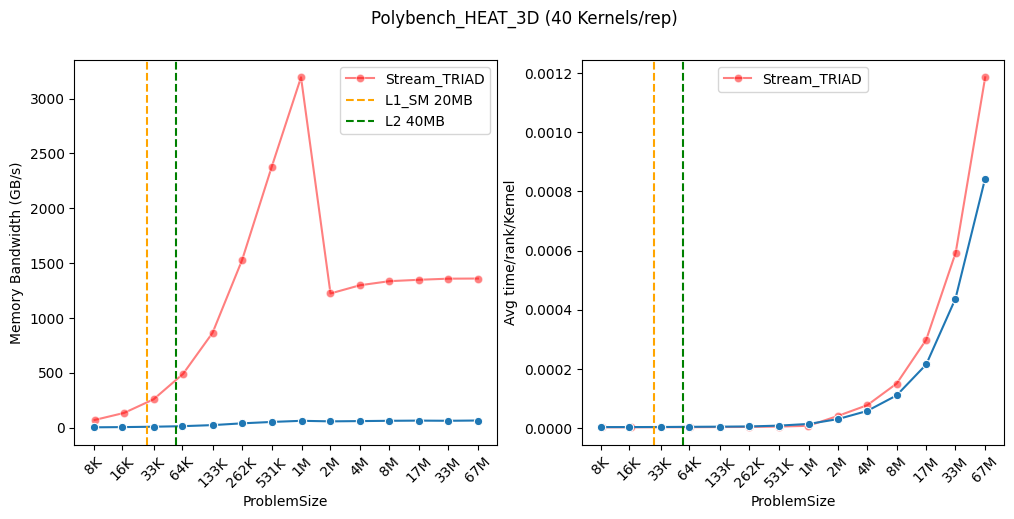

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                                2.826462              0.000003
16384                               5.627831              0.000003
32768                              10.937797              0.000003
65536                              21.042634              0.000003
131072                             39.624577              0.000003
262144                             64.266464              0.000004
524288                             98.741353              0.000005
1048576                           135.826149              0.000008
2097152                           131.296970              0.000016
4194304                            79.710815              0.000053
8388608                            83.219093              0.000101
16777216                           84.821824              0.000198
33554432                           85.808215              0.00

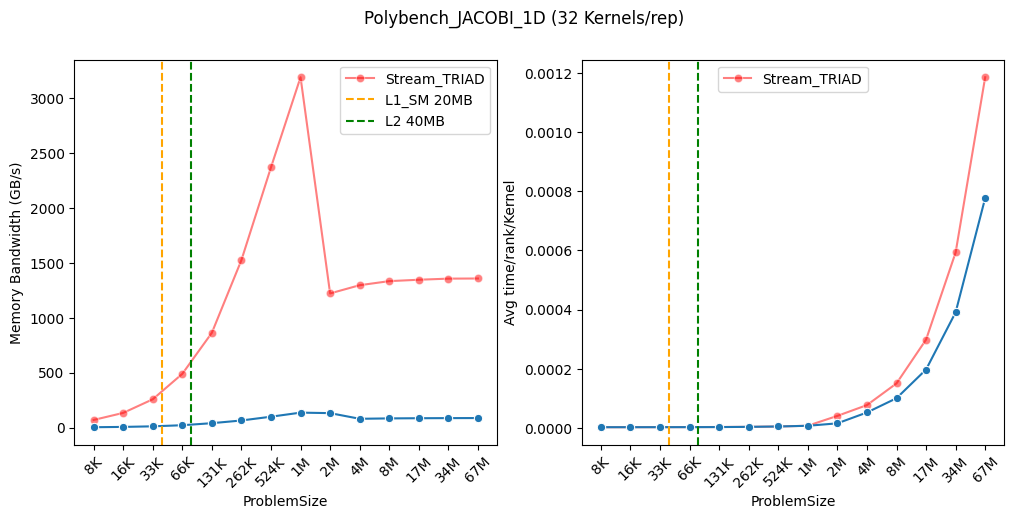

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                                1.111384              0.000119
16384                               2.172060              0.000123
32768                               4.055766              0.000131
65536                               7.582011              0.000139
131072                             14.018940              0.000150
262144                             23.005138              0.000183
524288                             34.237769              0.000246
1048576                            44.856753              0.000375
2097152                            35.093068              0.000957
4194304                            31.028371              0.002165
8388608                            32.081365              0.004186
16777216                           32.614856              0.008234
33554432                           32.964560              0.01

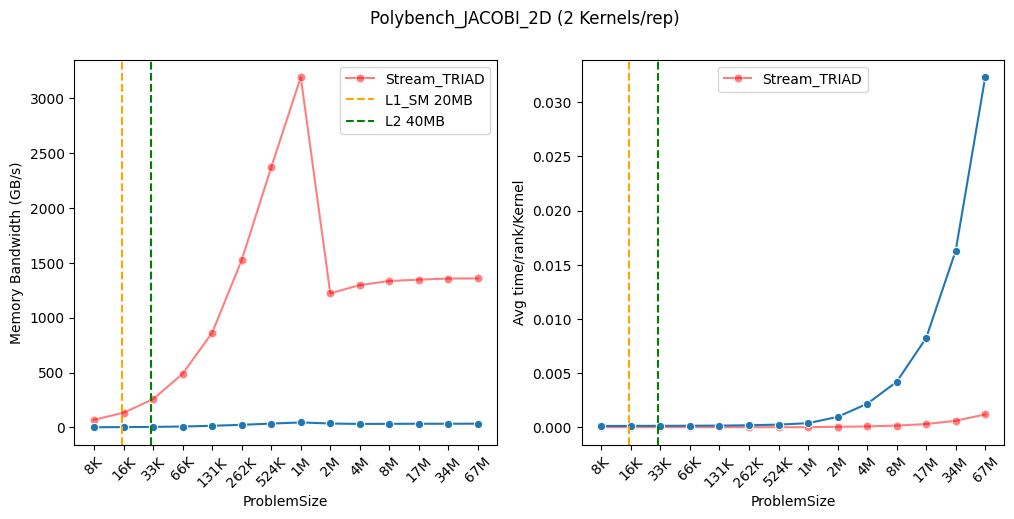

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                                7.109659              0.000009
16384                               9.178346              0.000015
32768                              15.855669              0.000017
65536                              13.727591              0.000039
131072                             27.913928              0.000038
262144                             28.000494              0.000075
524288                             52.750820              0.000080
1048576                            57.873379              0.000145
2097152                            98.292689              0.000171
4194304                            90.338699              0.000372
8388608                           125.453762              0.000535
16777216                          170.472387              0.000788
33554432                          255.388144              0.00

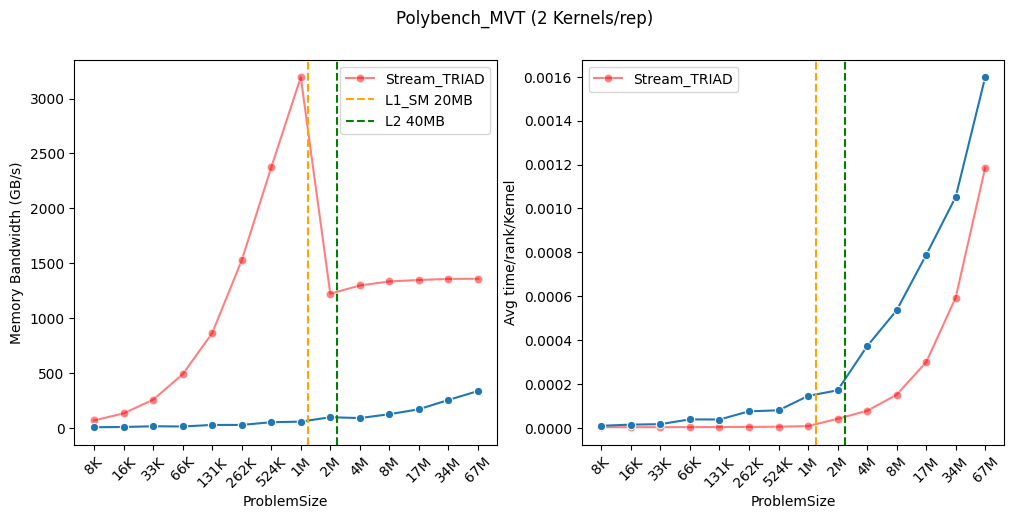

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                               68.798132              0.000003
16384                             133.306031              0.000003
32768                             255.918859              0.000003
65536                             489.220690              0.000003
131072                            868.410446              0.000004
262144                           1571.591868              0.000004
524288                           2394.275694              0.000005
1048576                          3201.266625              0.000008
2097152                          1218.470978              0.000041
4194304                          1296.635017              0.000078
8388608                          1335.938718              0.000151
16777216                         1348.337671              0.000299
33554432                         1352.992034              0.00

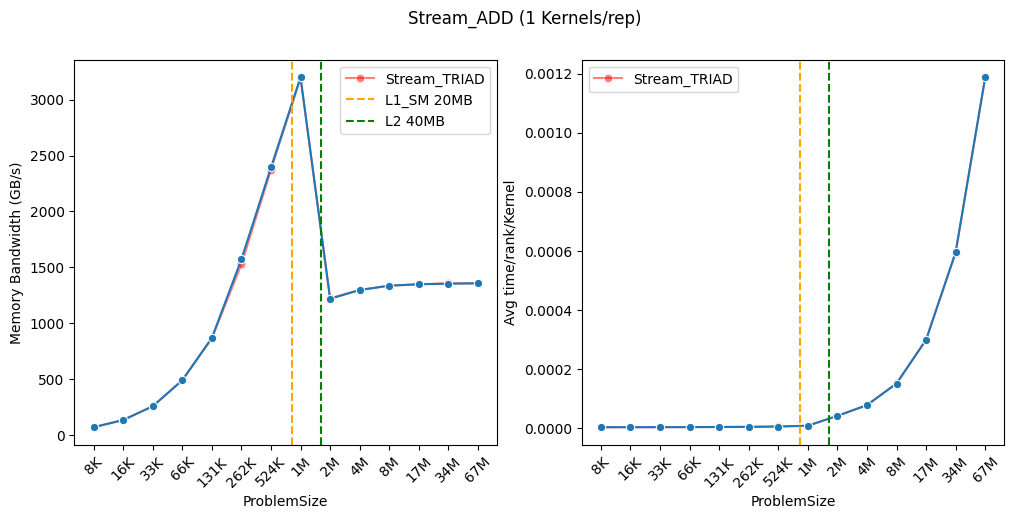

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                               49.012009              0.000003
16384                              96.254148              0.000003
32768                             182.638866              0.000003
65536                             358.414817              0.000003
131072                            656.044741              0.000003
262144                           1128.163150              0.000004
524288                           1757.154308              0.000005
1048576                          2495.454816              0.000007
2097152                          1288.938817              0.000026
4194304                          1282.480522              0.000052
8388608                          1336.413603              0.000100
16777216                         1364.699822              0.000197
33554432                         1379.969292              0.00

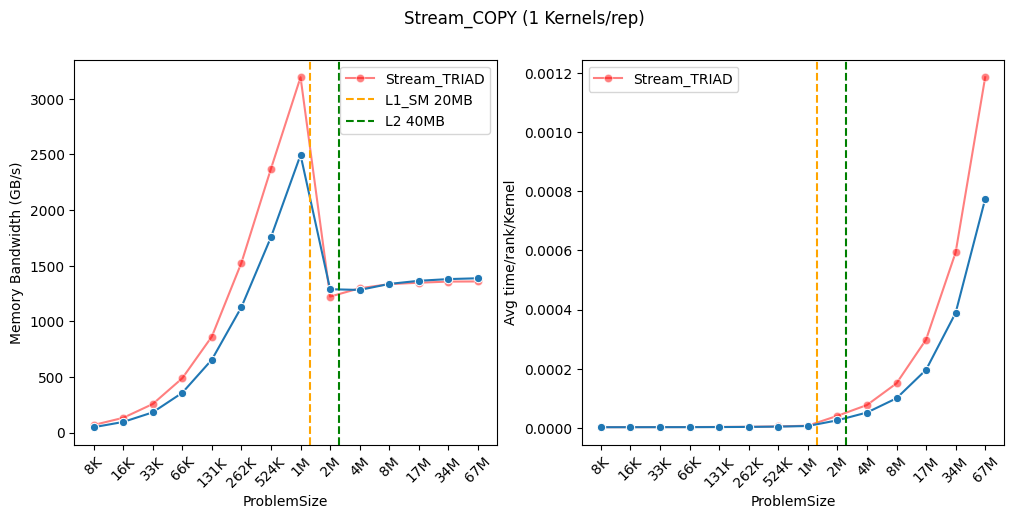

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                               48.032444              0.000003
16384                              91.931572              0.000003
32768                             178.270569              0.000003
65536                             337.010992              0.000003
131072                            644.854066              0.000003
262144                           1114.404417              0.000004
524288                           1718.995371              0.000005
1048576                          2469.420364              0.000007
2097152                          1295.104978              0.000026
4194304                          1277.607965              0.000053
8388608                          1336.320758              0.000100
16777216                         1365.516680              0.000197
33554432                         1379.216936              0.00

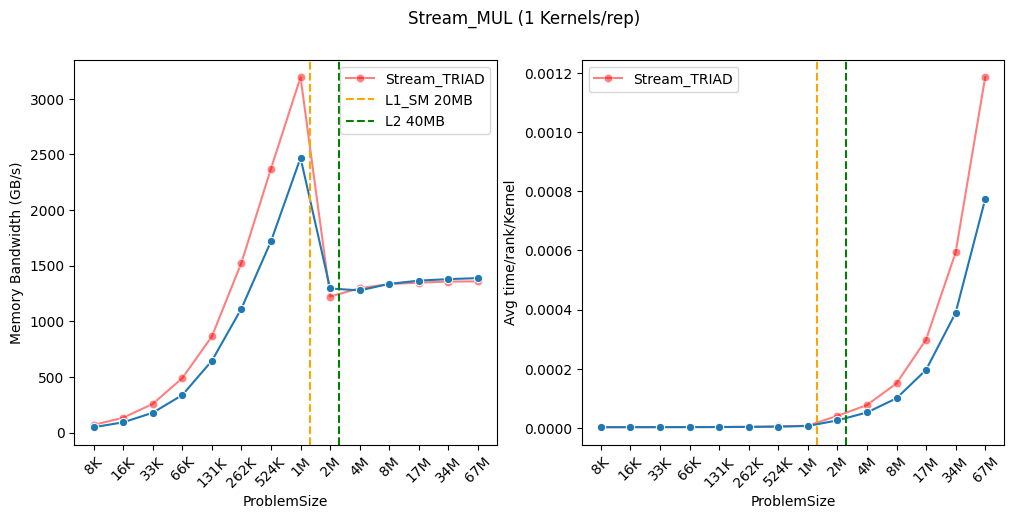

                     Memory Bandwidth (GB/s)  Avg time/rank/Kernel
ProblemSizeRunParam                                               
8192                               69.089406              0.000003
16384                             133.296451              0.000003
32768                             257.492315              0.000003
65536                             489.305613              0.000003
131072                            863.804791              0.000004
262144                           1526.664858              0.000004
524288                           2372.249590              0.000005
1048576                          3193.823637              0.000008
2097152                          1222.668768              0.000041
4194304                          1297.579023              0.000078
8388608                          1334.670123              0.000151
16777216                         1347.394677              0.000299
33554432                         1357.498297              0.00

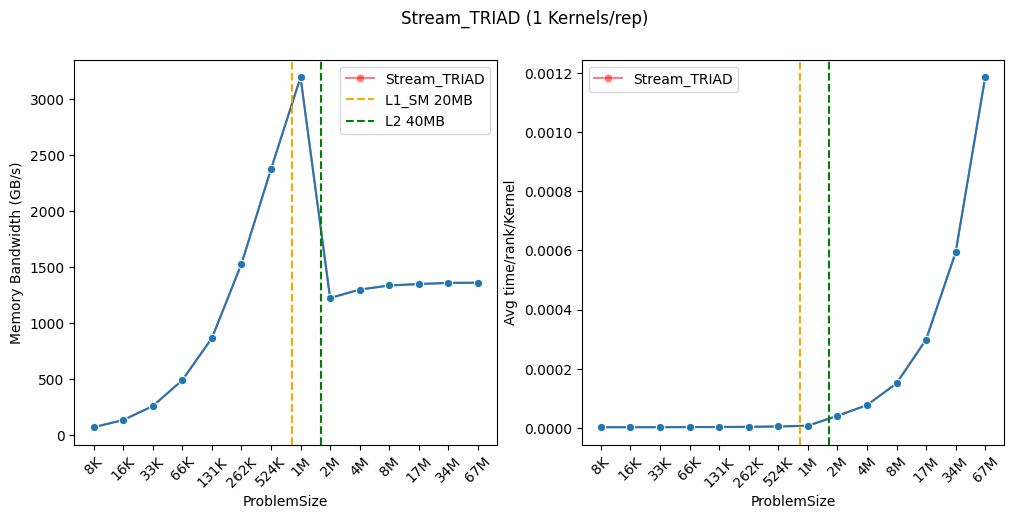

In [34]:
for node in set(tk.dataframe.index.get_level_values("node")):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Add "Stream_TRIAD" data in red
    stream_triad_data = tk.dataframe.loc[tk.get_node("Stream_TRIAD")]
    sns.lineplot(
        data=stream_triad_data,
        x="ProblemSize_mean",
        y="Memory Bandwidth (GB/s)",
        marker="o",
        ax=ax[0],
        color='red',
        label="Stream_TRIAD",
        alpha=0.5,
    )
    sns.lineplot(
        data=stream_triad_data,
        x="ProblemSize_mean",
        y="Avg time/rank/Kernel",
        marker="o",
        ax=ax[1],
        color='red',
        label="Stream_TRIAD",
        alpha=0.5,
    )

    # Node data
    data = tk.dataframe.loc[node]
    sns.lineplot(
        data=data, 
        x="ProblemSize_mean",
        y="Memory Bandwidth (GB/s)",
        marker="o",
        ax=ax[0],
    )
    sns.lineplot(
        data=data, 
        x="ProblemSize_mean",
        y="Avg time/rank/Kernel",
        marker="o",
        ax=ax[1],
    )

    print(data[["Memory Bandwidth (GB/s)", "Avg time/rank/Kernel"]])

    fig.suptitle(f'{node.frame["name"]} ({int(tk.dataframe.loc[node, "Kernels/Rep_mean"].iloc[0])} Kernels/rep)')

    l1 = 192000
    l1_sm = l1 * 108
    l2 = 40960000
    HBM = 4e+10

    # Normalize by bytes/problem to have ProblemSize on x-axis
    bytes_per_probsize = data["Bytes/Rep/Problem Size"].iloc[0]
    l1_sm = l1_sm / bytes_per_probsize
    l2 = l2 / bytes_per_probsize
    HBM = HBM / bytes_per_probsize

    ax[0].axvline(x=l1_sm, color='orange', linestyle='--', label='L1_SM 20MB') # -> (192KB * 108SM = 20MB)
    ax[0].axvline(x=l2, color='g', linestyle='--', label=f'L2 40MB')
    #ax[0].axvline(x=HBM, color='r', linestyle='--', label=f'HBM 40GB')
    ax[1].axvline(x=l1_sm, color='orange', linestyle='--', label='L1_SM 20MB') # -> (192KB * 108SM = 20MB)
    ax[1].axvline(x=l2, color='g', linestyle='--', label=f'L2 40MB')
    ax[0].legend()

    # Apply log scale to both subplots
    ax[0].set_xscale('log', base=2)
    ax[1].set_xscale('log', base=2)

    def format_large_numbers(value):
        if value >= 1_000_000:
            return f"{value / 1_000_000:.0f}M"
        elif value >= 1_000:
            return f"{value / 1_000:.0f}K"
        else:
            return str(value)

    # Set formatted x-ticks for both subplots
    for i in range(2):
        ax[i].set_xticks(data["ProblemSize_mean"])
        ax[i].set_xticklabels([format_large_numbers(x) for x in data["ProblemSize_mean"]], rotation=45)

    # strip _mean
    for i in range(2):
        current_label = ax[i].get_xlabel()
        ax[i].set_xlabel(current_label.replace("_mean", ""))


    plt.show()


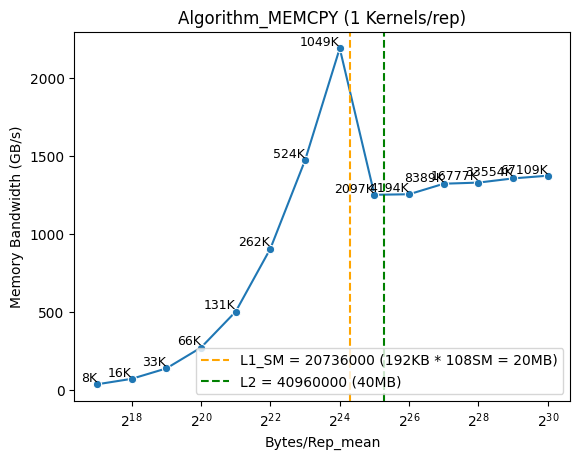

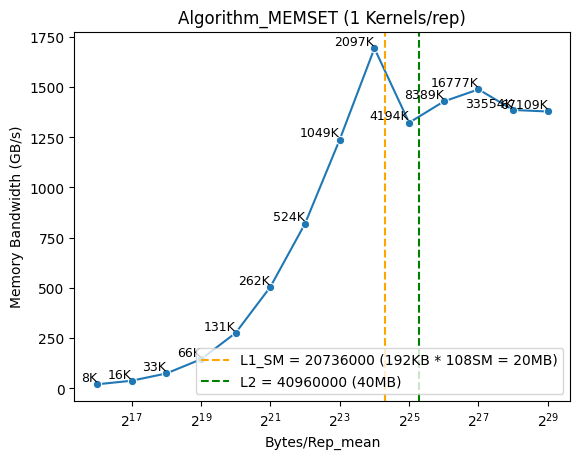

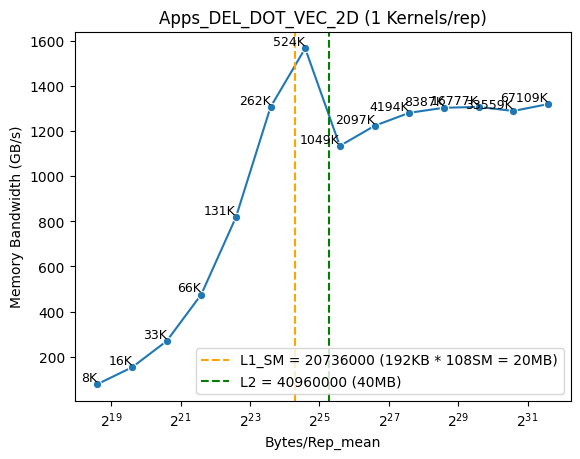

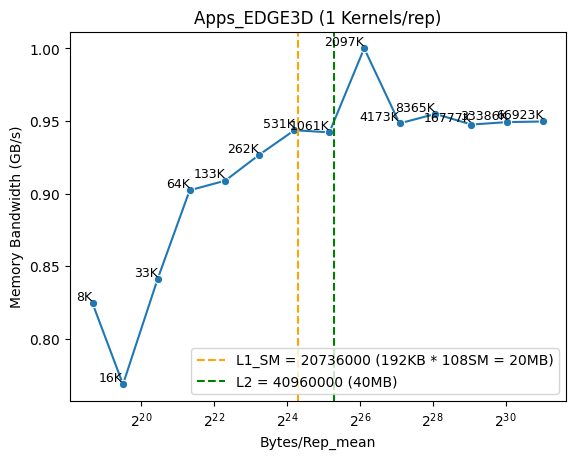

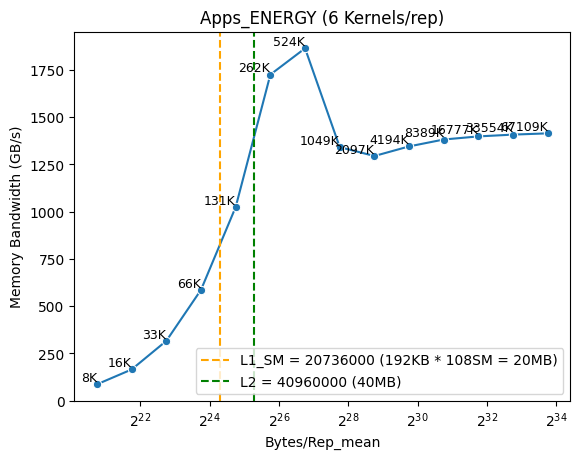

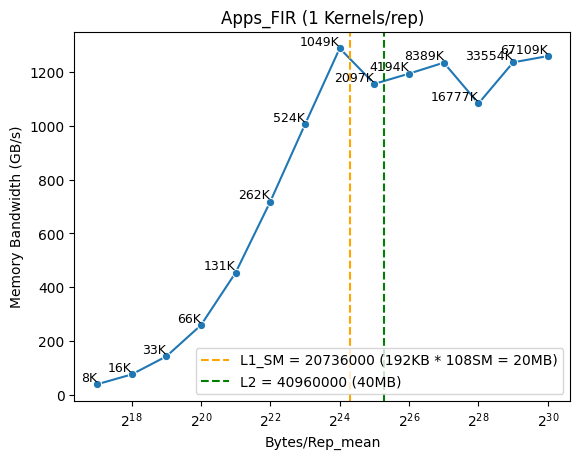

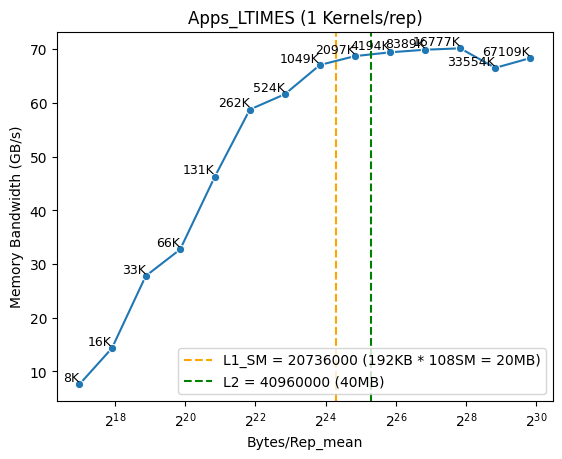

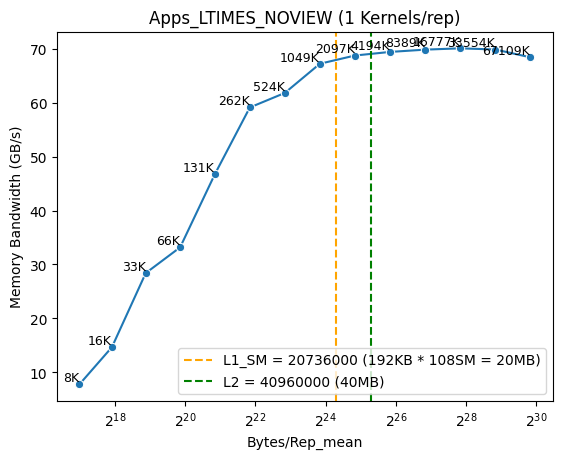

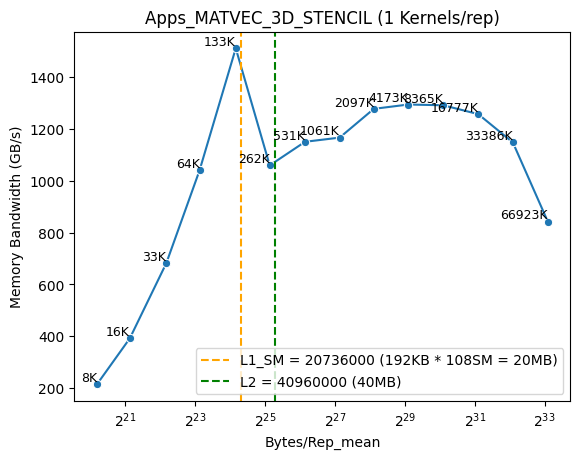

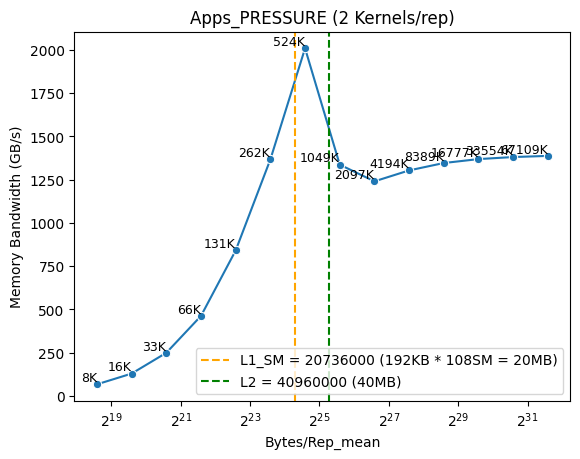

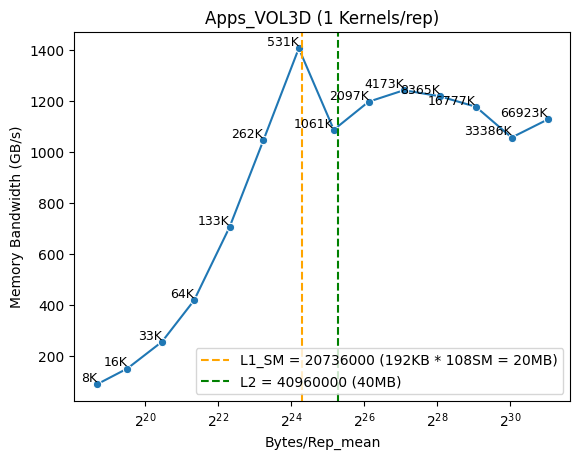

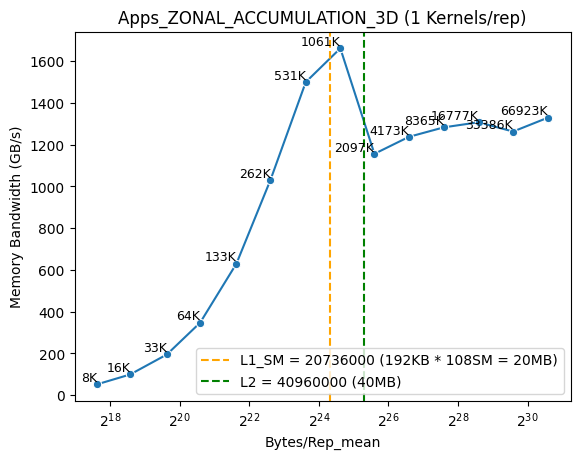

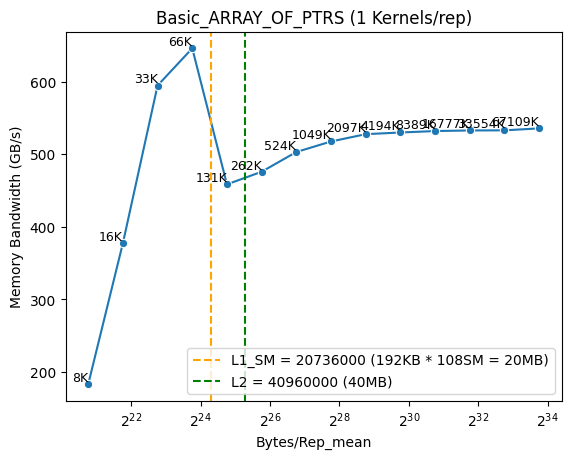

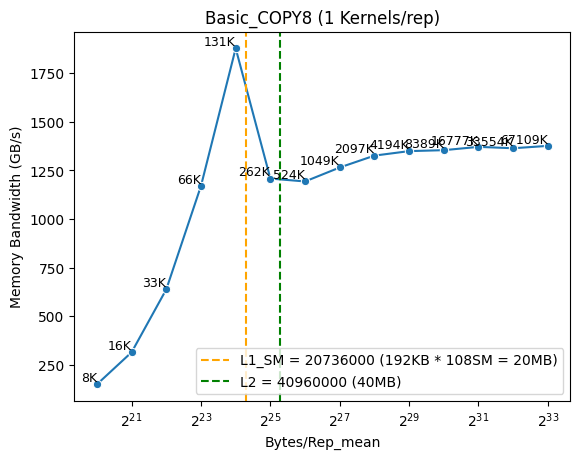

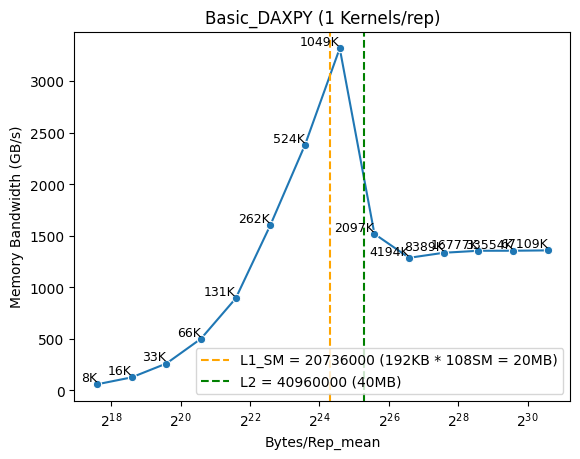

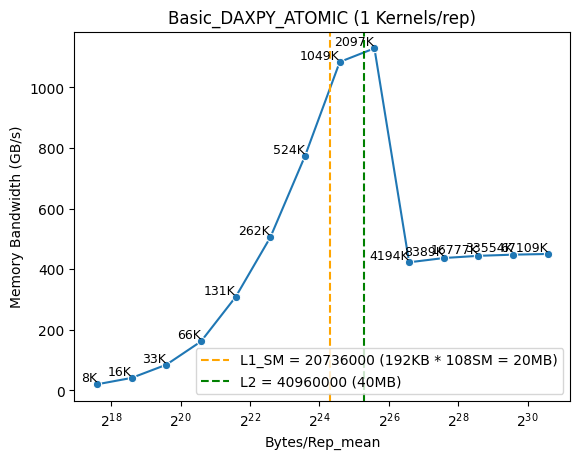

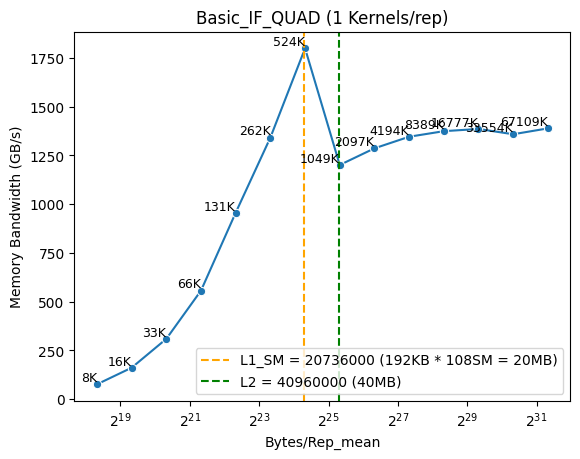

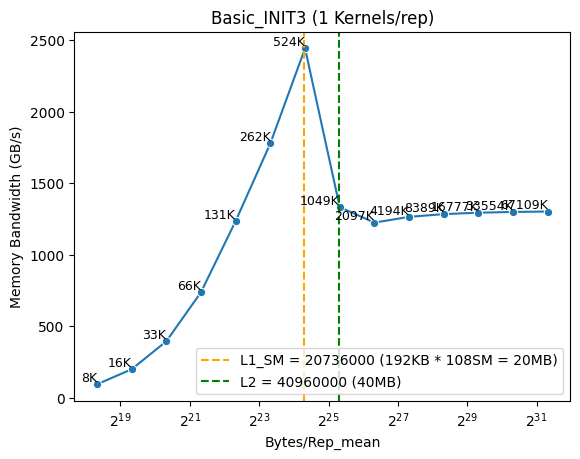

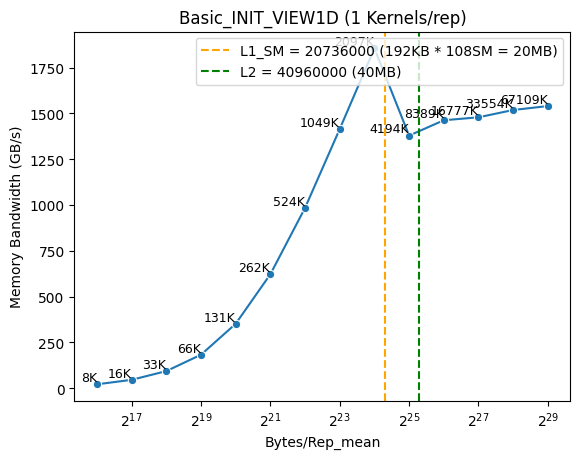

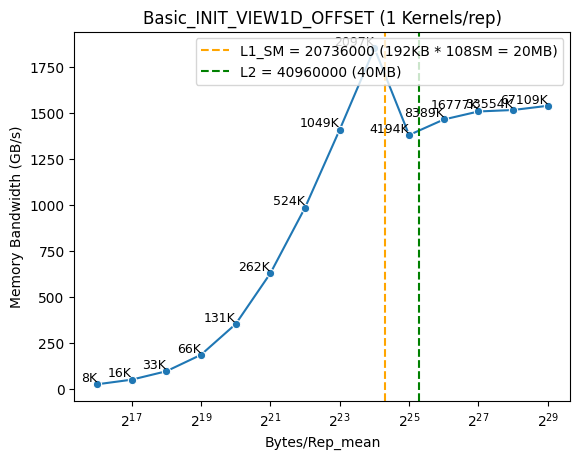

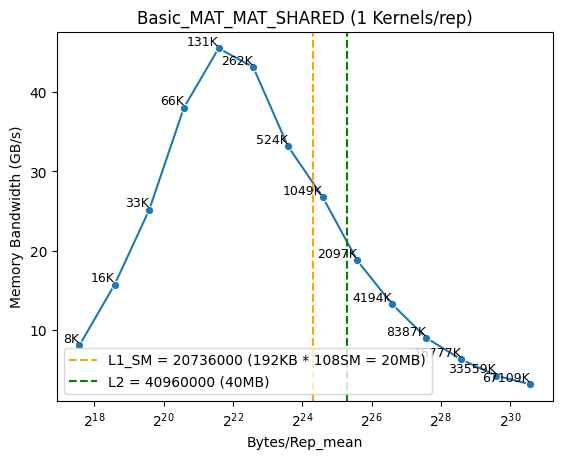

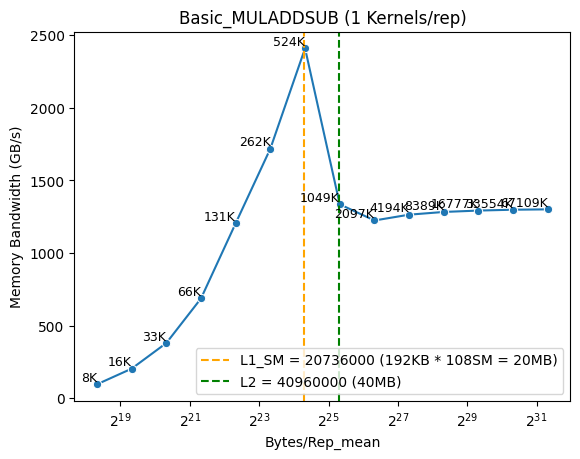

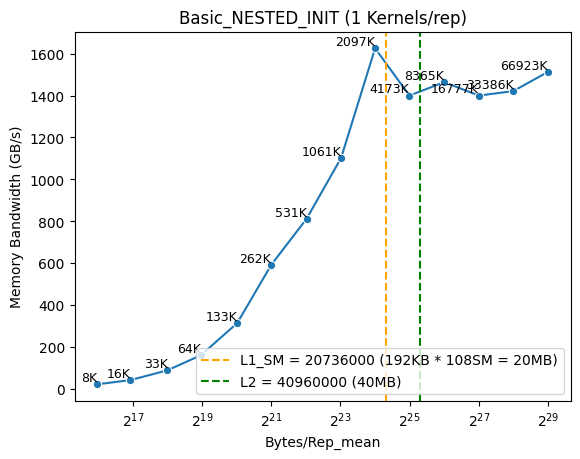

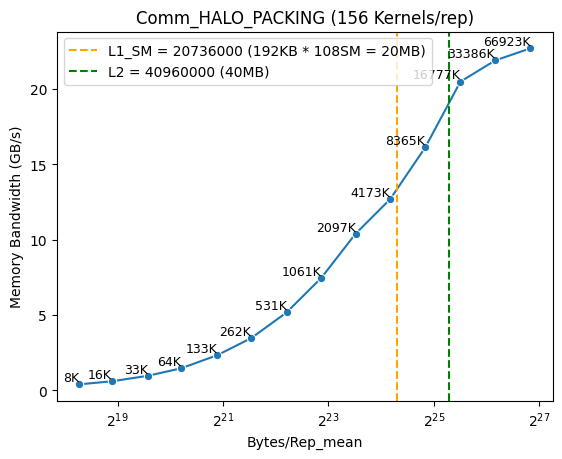

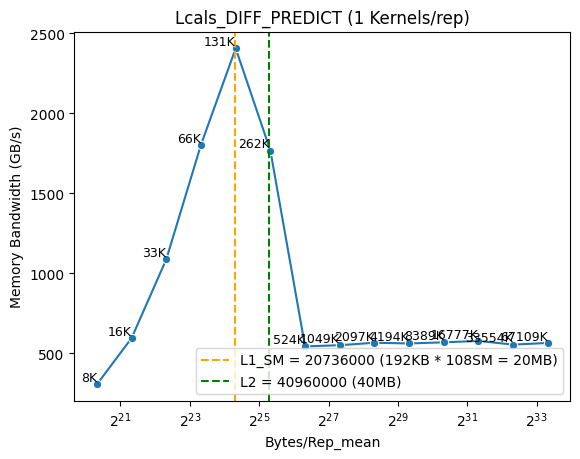

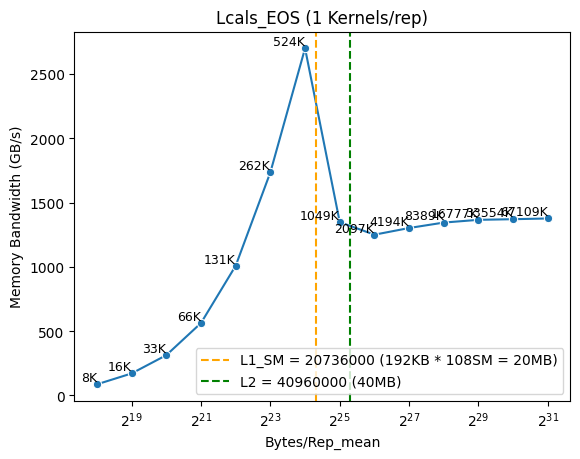

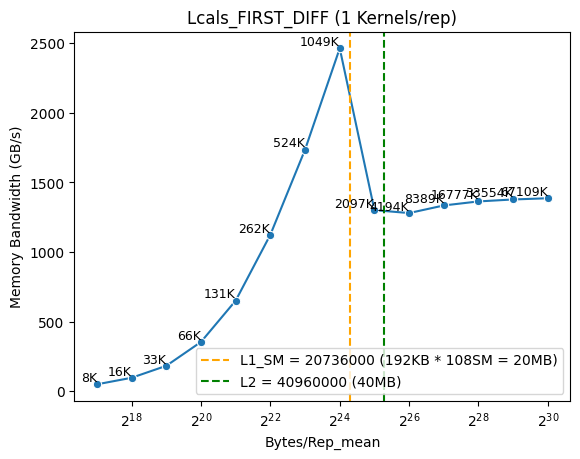

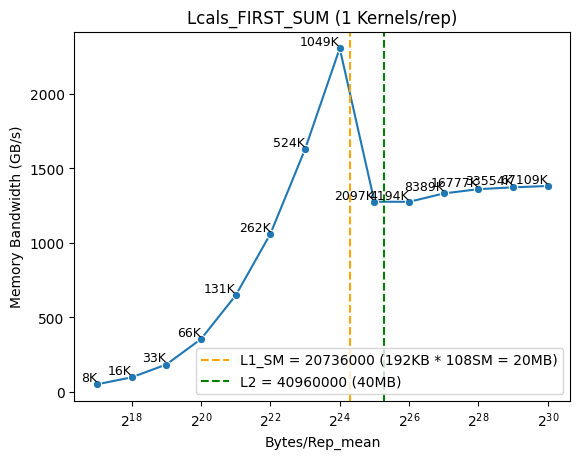

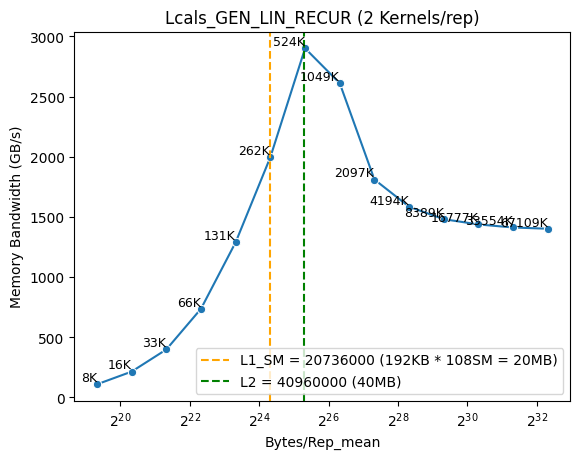

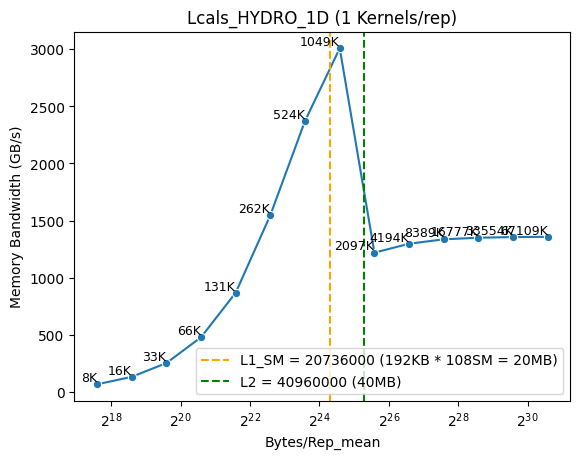

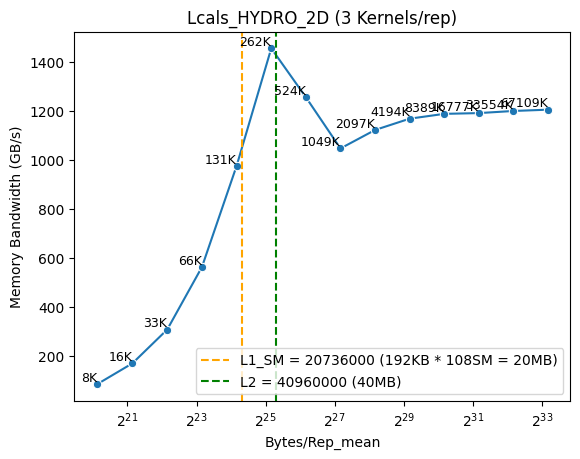

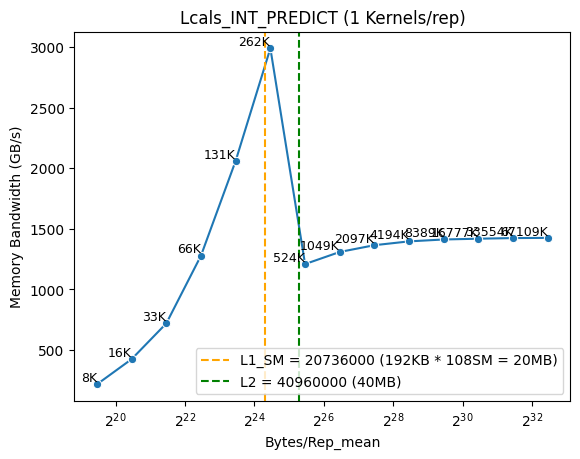

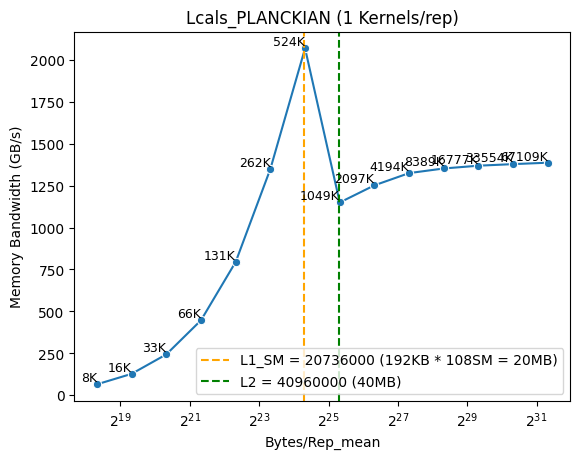

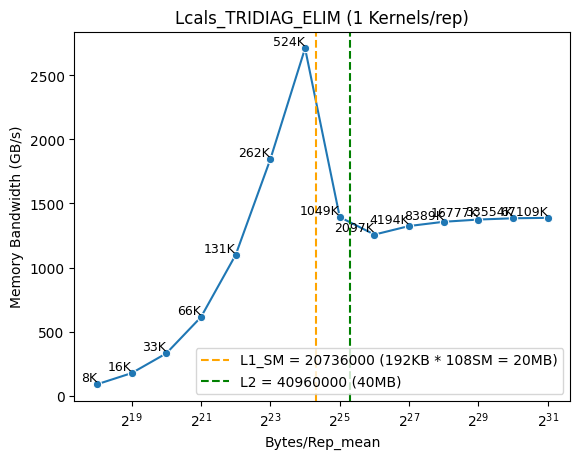

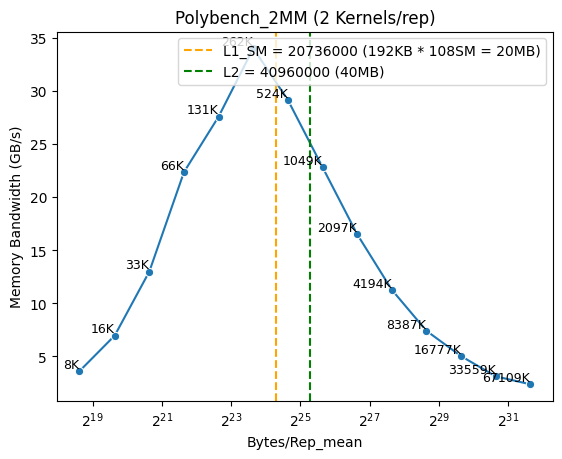

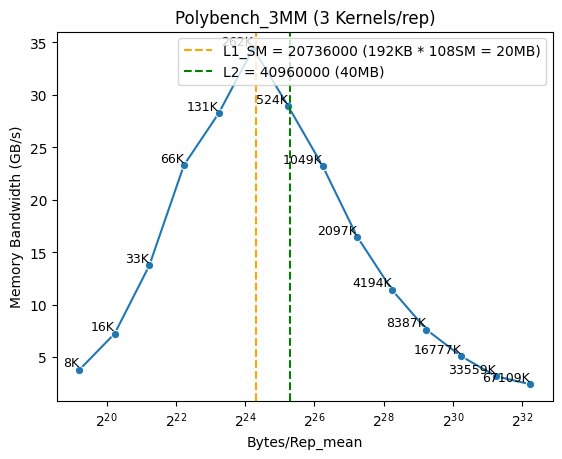

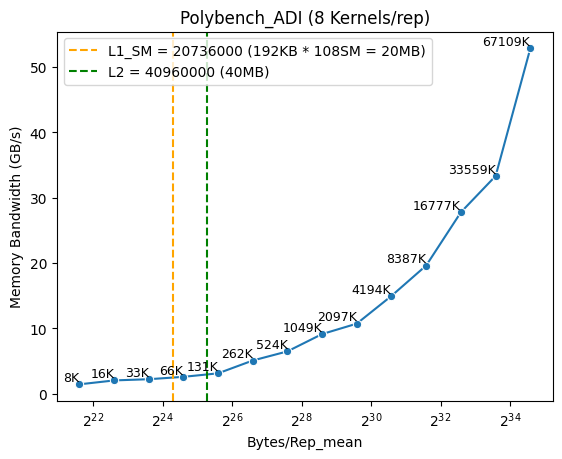

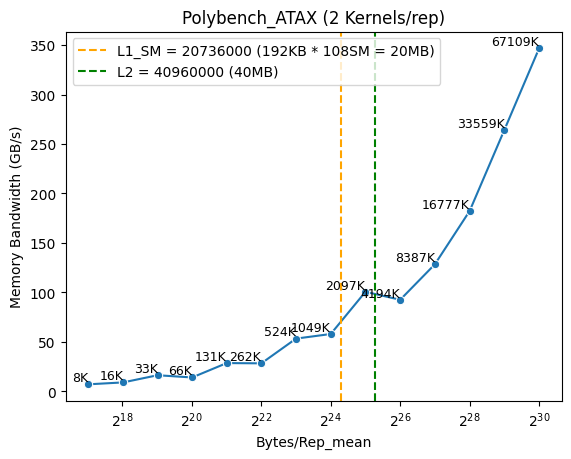

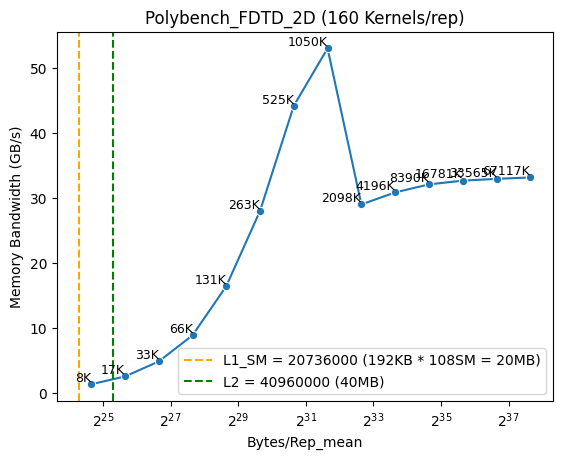

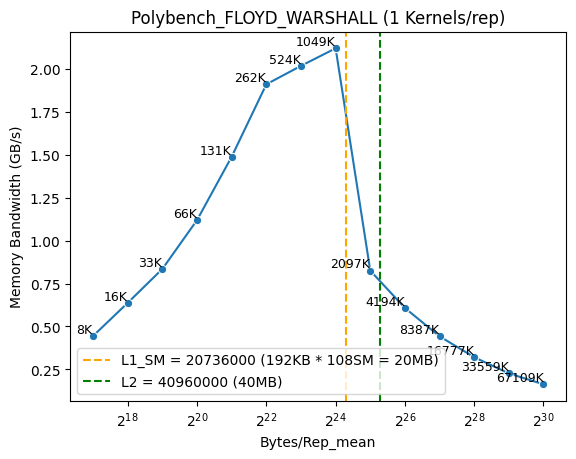

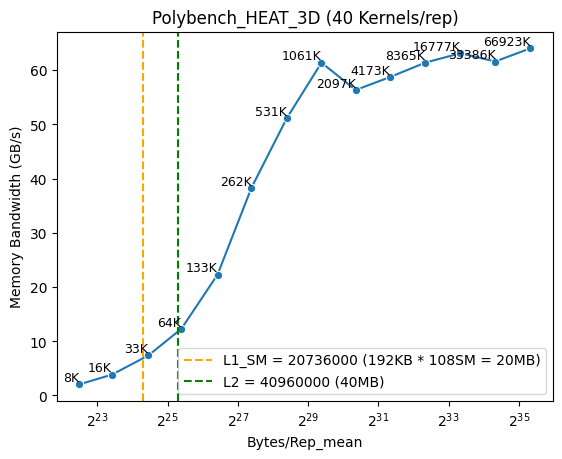

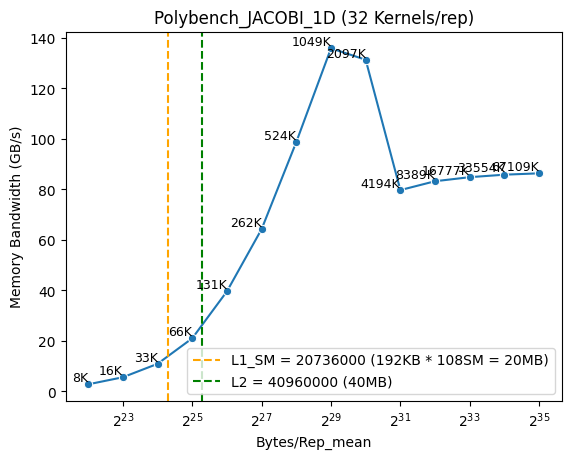

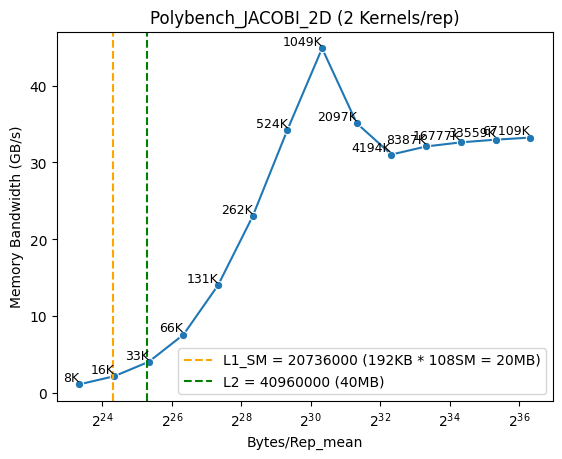

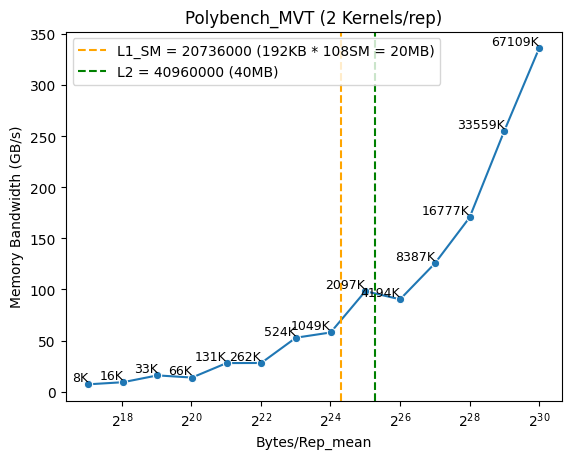

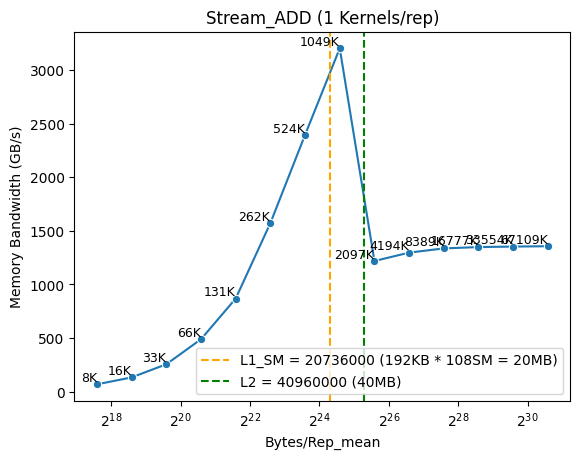

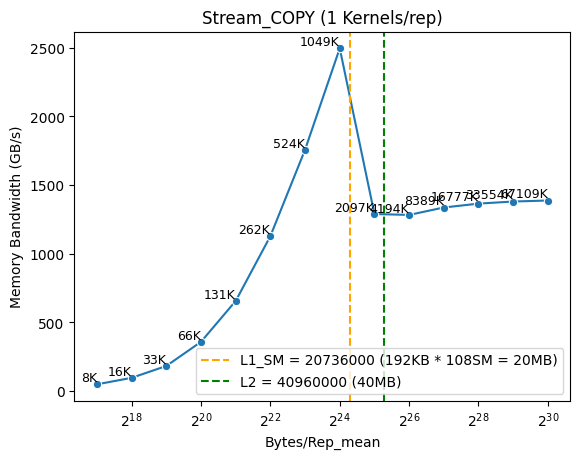

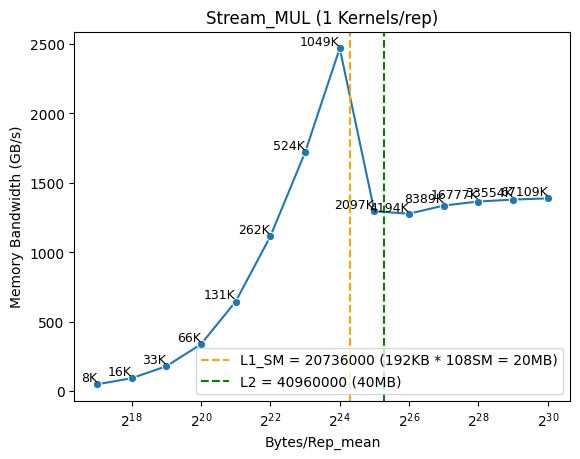

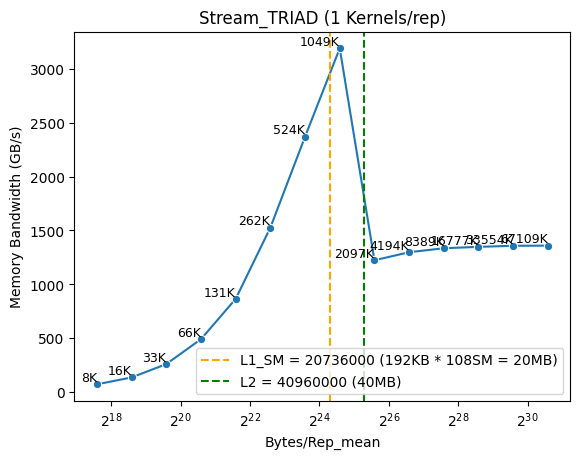

In [ ]:
for node in set(tk.dataframe.index.get_level_values("node")):
    sns.lineplot(
        data=tk.dataframe.loc[node], 
        x="Bytes/Rep_mean",
        y="Memory Bandwidth (GB/s)",
        marker="o"   
    )
    plt.title(f'{node.frame["name"]} ({int(tk.dataframe.loc[node, "Kernels/Rep_mean"].iloc[0])} Kernels/rep)')

    l1 = 192000
    l1_sm = l1 * 108
    l2 = 40960000


    plt.axvline(x=l1_sm, color='orange', linestyle='--', label=f'L1_SM = {l1_sm} (192KB * 108SM = 20MB)')
    plt.axvline(x=l2, color='g', linestyle='--', label=f'L2 = {l2} (40MB)')

    # Annotate each data point with the corresponding value
    for x, y, ps in zip(
        tk.dataframe.loc[node]["Bytes/Rep_mean"], 
        tk.dataframe.loc[node]["Memory Bandwidth (GB/s)"], 
        tk.dataframe.loc[node]["ProblemSize_mean"]
    ):
        plt.text(x, y, f"{ps/10**3:.0f}K", fontsize=9, ha='right', va='bottom')

    plt.legend()
    plt.xscale('log', base=2)

    plt.show()
